In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [14]:
# Load Dataset
df_trans = pd.read_csv('../data/eda/transactions_unified.csv')
df_acc = pd.read_csv('../data/eda/accounts_unified.csv')
df_cust = pd.read_csv('../data/eda/customers_unified.csv')

print(f"✅ Transactions: {df_trans.shape[0]:,} rows")
print(f"✅ Accounts:     {df_acc.shape[0]:,} rows")
print(f"✅ Customers:    {df_cust.shape[0]:,} rows")

✅ Transactions: 48,510 rows
✅ Accounts:     1,651 rows
✅ Customers:    1,100 rows


# UNIVARIATE ANALYSIS

In [15]:
# Check all columns in transactions to see what's available
print("\n📋 Available columns in transactions:")
print(df_trans.columns.tolist())

# Check for fraud-related columns
fraud_columns = [col for col in df_trans.columns if 'fraud' in col.lower()]
if fraud_columns:
    print(f"\n✅ Fraud columns found: {fraud_columns}")
else:
    print("\n⚠️ No fraud columns found. This is a synthetic dataset without fraud labels.")


📋 Available columns in transactions:
['TransactionID', 'AccountOriginID', 'AccountDestinationID', 'TransactionTypeID', 'Amount', 'TransactionDate', 'BranchID', 'Description', 'AccountID', 'OriginCustomerID', 'OriginAccountTypeID', 'OriginAccountStatusID', 'OriginBalance', 'OriginOpeningDate', 'AccountID_dest', 'DestCustomerID', 'DestAccountTypeID', 'DestAccountStatusID', 'DestBalance', 'DestOpeningDate', 'CustomerID', 'OriginFirstName', 'OriginLastName', 'OriginDateOfBirth', 'OriginAddressID', 'OriginCustomerTypeID', 'CustomerID_dest', 'DestFirstName', 'DestLastName', 'DestDateOfBirth', 'DestAddressID', 'DestCustomerTypeID', 'TypeName', 'BranchName', 'AddressID']

⚠️ No fraud columns found. This is a synthetic dataset without fraud labels.


# Who are the customers?


👤 QUESTION 1: Who are the customers?

📊 Customer Distribution:
   Large Enterprise: 397 (36.1%)
   Small Business: 352 (32.0%)
   Individual: 351 (31.9%)


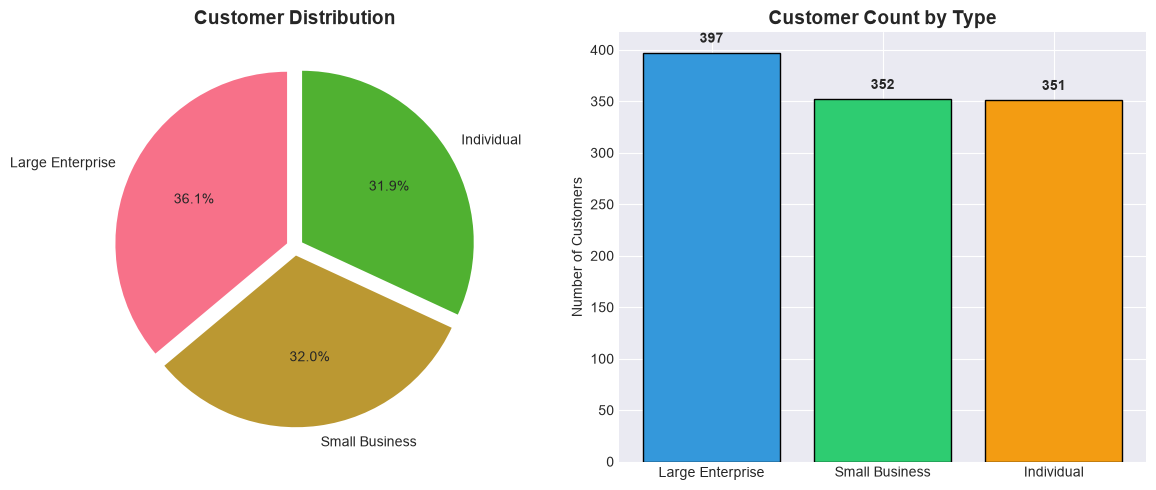

In [16]:
print("\n" + "="*80)
print("👤 QUESTION 1: Who are the customers?")
print("="*80)

# Customer type distribution
if 'TypeName' in df_cust.columns:
    print(f"\n📊 Customer Distribution:")
    cust_types = df_cust['TypeName'].value_counts()
    for ctype, count in cust_types.items():
        pct = (count / len(df_cust)) * 100
        print(f"   {ctype}: {count:,} ({pct:.1f}%)")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Pie chart
    axes[0].pie(cust_types.values, labels=cust_types.index, autopct='%1.1f%%', startangle=90, explode=[0.05]*len(cust_types))
    axes[0].set_title('Customer Distribution', fontsize=14, fontweight='bold')
    
    # Bar chart
    axes[1].bar(cust_types.index, cust_types.values, color=['#3498db', '#2ecc71', '#f39c12'], edgecolor='black')
    axes[1].set_title('Customer Count by Type', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Customers')
    for i, v in enumerate(cust_types.values):
        axes[1].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()



## What are the account patterns?


💳 QUESTION 2: What are the account patterns?

📊 Account Type Distribution:
   Business: 360 (21.8%)
   Youth: 336 (20.4%)
   Savings: 333 (20.2%)
   Payroll: 311 (18.8%)
   Checking: 311 (18.8%)


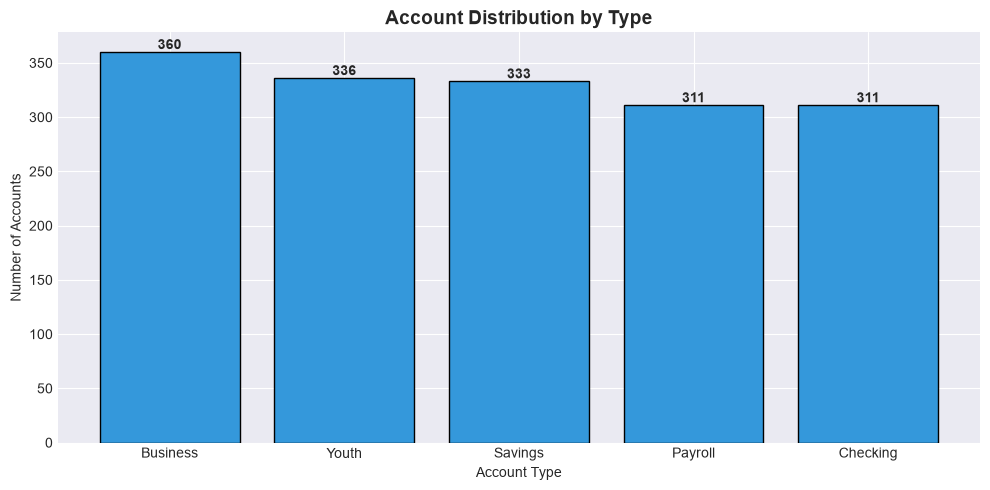


📊 Account Status Distribution:
   Active: 1,327 (80.4%)
   Inactive: 250 (15.1%)
   Closed: 74 (4.5%)


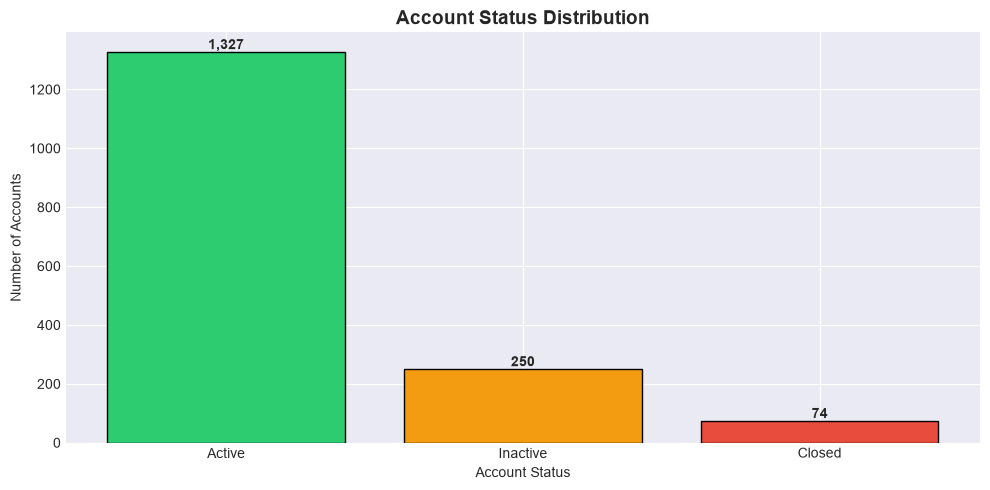

In [17]:
print("\n" + "="*80)
print("💳 QUESTION 2: What are the account patterns?")
print("="*80)

# Account type distribution
if 'TypeName' in df_acc.columns:
    acc_types = df_acc['TypeName'].value_counts()
    print(f"\n📊 Account Type Distribution:")
    for atype, count in acc_types.items():
        pct = (count / len(df_acc)) * 100
        print(f"   {atype}: {count:,} ({pct:.1f}%)")
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(acc_types.index, acc_types.values, color='#3498db', edgecolor='black')
    plt.title('Account Distribution by Type', fontsize=14, fontweight='bold')
    plt.xlabel('Account Type')
    plt.ylabel('Number of Accounts')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Account status distribution
if 'StatusName' in df_acc.columns:
    acc_status = df_acc['StatusName'].value_counts()
    print(f"\n📊 Account Status Distribution:")
    for status, count in acc_status.items():
        pct = (count / len(df_acc)) * 100
        print(f"   {status}: {count:,} ({pct:.1f}%)")
    
    plt.figure(figsize=(10, 5))
    colors = ['#2ecc71' if s == 'Active' else '#f39c12' if s == 'Inactive' else '#e74c3c' for s in acc_status.index]
    bars = plt.bar(acc_status.index, acc_status.values, color=colors, edgecolor='black')
    plt.title('Account Status Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Account Status')
    plt.ylabel('Number of Accounts')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

# What are the loan patterns?


🏠 QUESTION 3: What are the loan patterns?

📊 Loan Status Distribution:
   Status 1: 239 (72.4%)
   Status 2: 57 (17.3%)
   Status 3: 34 (10.3%)


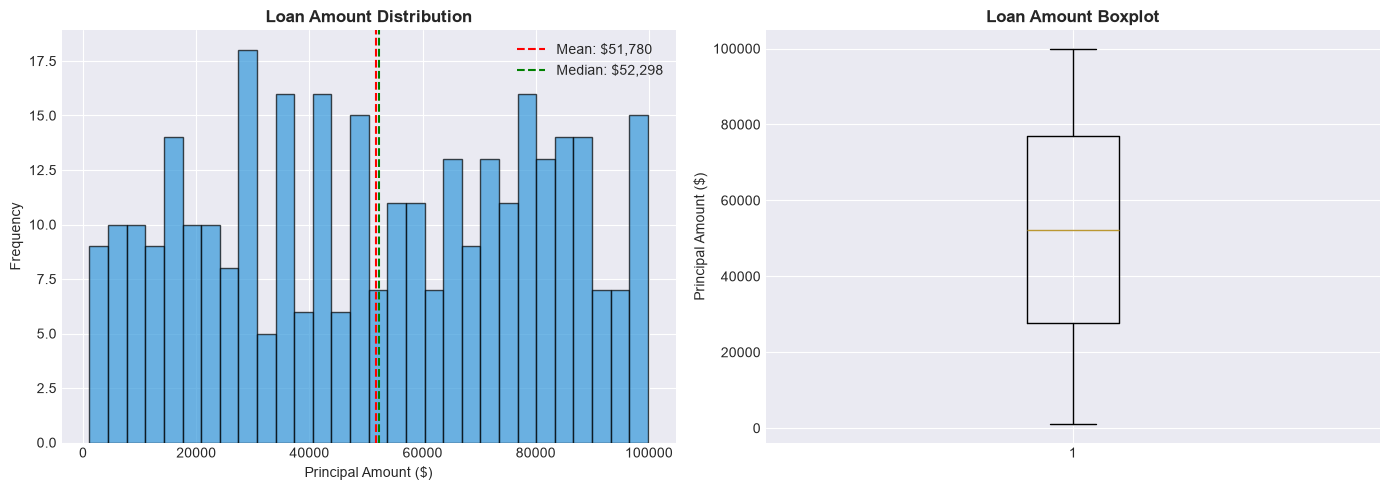

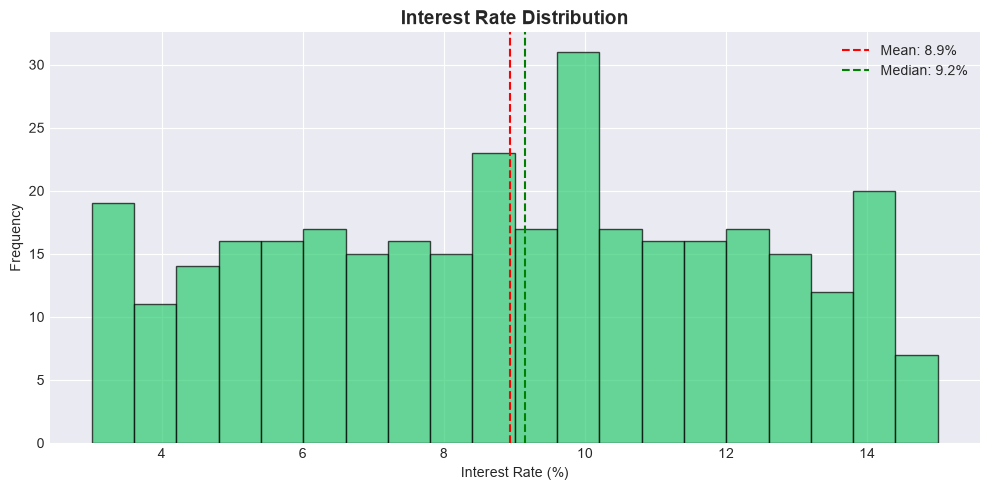

In [18]:
print("\n" + "="*80)
print("🏠 QUESTION 3: What are the loan patterns?")
print("="*80)

# Loan status distribution
if 'loans' in locals() or 'df_acc' in locals():
    # Check if loans data is available
    if 'LoanStatusID' in df_acc.columns:
        # Use account-level data for loan stats
        loan_status = df_acc['LoanStatusID'].value_counts()
        print(f"\n📊 Loan Status Distribution:")
        print(loan_status.to_string())
    
    # If we have loan data loaded separately
    try:
        df_loans = pd.read_csv('../data/processed/loans.csv')
        loan_status = df_loans['LoanStatusID'].value_counts()
        print(f"\n📊 Loan Status Distribution:")
        for status, count in loan_status.items():
            pct = (count / len(df_loans)) * 100
            print(f"   Status {status}: {count:,} ({pct:.1f}%)")
        
        # Plot loan amounts distribution
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Histogram of loan amounts
        axes[0].hist(df_loans['PrincipalAmount'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0].axvline(df_loans['PrincipalAmount'].mean(), color='red', linestyle='--', label=f'Mean: ${df_loans["PrincipalAmount"].mean():,.0f}')
        axes[0].axvline(df_loans['PrincipalAmount'].median(), color='green', linestyle='--', label=f'Median: ${df_loans["PrincipalAmount"].median():,.0f}')
        axes[0].set_title('Loan Amount Distribution', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Principal Amount ($)')
        axes[0].set_ylabel('Frequency')
        axes[0].legend()
        
        # Boxplot of loan amounts
        axes[1].boxplot(df_loans['PrincipalAmount'], vert=True)
        axes[1].set_title('Loan Amount Boxplot', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Principal Amount ($)')
        
        plt.tight_layout()
        plt.show()
        
        # Interest rate distribution
        plt.figure(figsize=(10, 5))
        plt.hist(df_loans['InterestRate'] * 100, bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
        plt.axvline(df_loans['InterestRate'].mean() * 100, color='red', linestyle='--', label=f'Mean: {df_loans["InterestRate"].mean()*100:.1f}%')
        plt.axvline(df_loans['InterestRate'].median() * 100, color='green', linestyle='--', label=f'Median: {df_loans["InterestRate"].median()*100:.1f}%')
        plt.title('Interest Rate Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Interest Rate (%)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
    except:
        print("\n   ℹ️ Loan details not available in current dataset")

## What are the transaction patterns?


💸 QUESTION 4: What are the transaction patterns?

📊 Transaction Amount Statistics:
   Mean: $2,504.29
   Median: $2,504.25
   Min: $1.01
   Max: $4,999.59
   Std Dev: $1,442.44


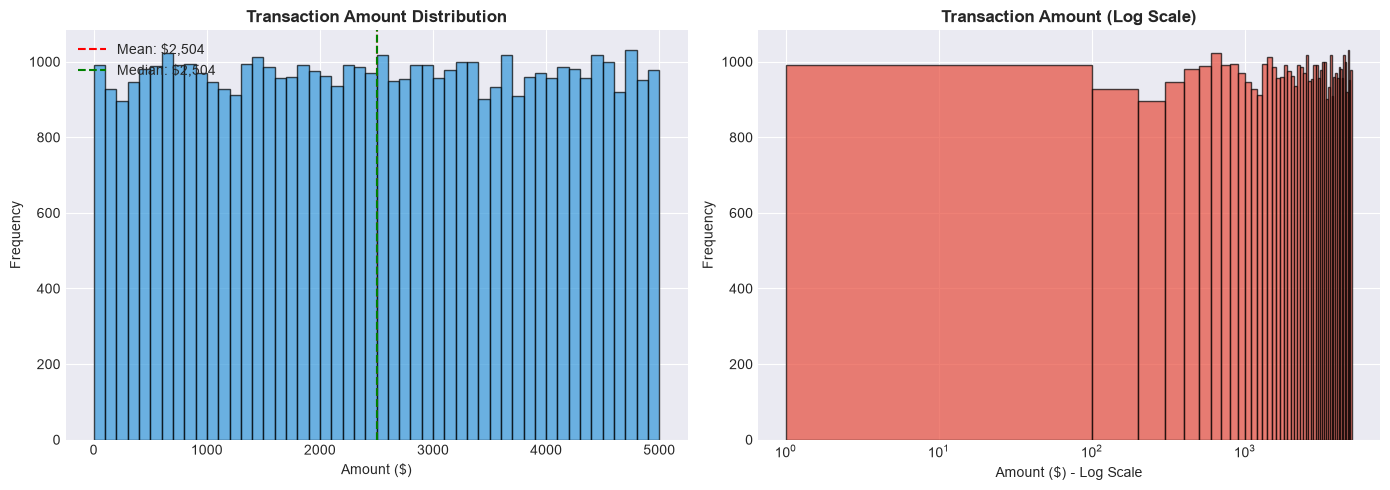


📊 Transaction by Type:
   Deposit: 14,760 (30.4%)
   Transfer: 14,478 (29.8%)
   Withdrawal: 14,412 (29.7%)
   Payment: 4,860 (10.0%)


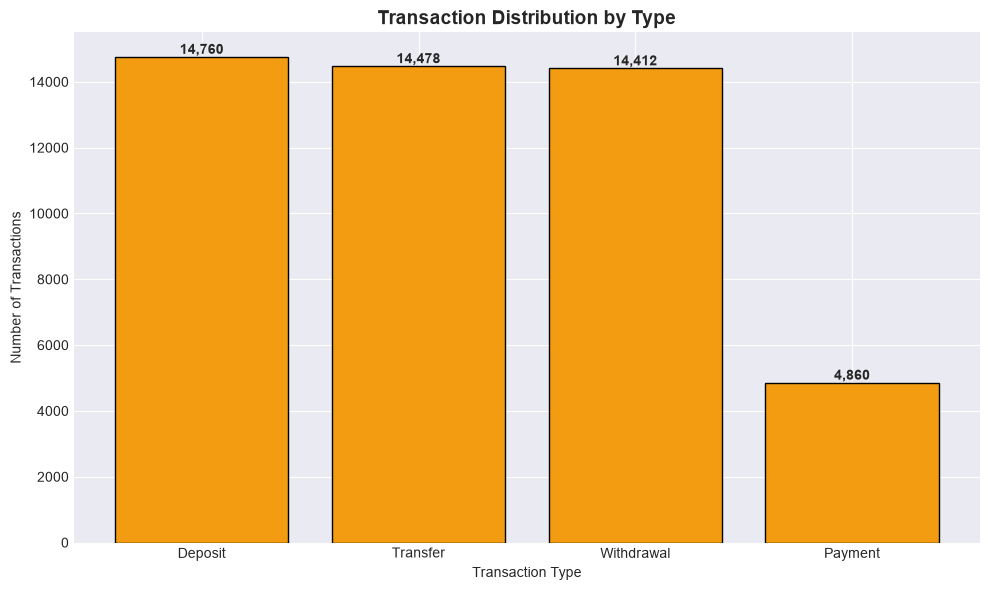

In [19]:
print("\n" + "="*80)
print("💸 QUESTION 4: What are the transaction patterns?")
print("="*80)

# Transaction amount distribution
print(f"\n📊 Transaction Amount Statistics:")
print(f"   Mean: ${df_trans['Amount'].mean():,.2f}")
print(f"   Median: ${df_trans['Amount'].median():,.2f}")
print(f"   Min: ${df_trans['Amount'].min():,.2f}")
print(f"   Max: ${df_trans['Amount'].max():,.2f}")
print(f"   Std Dev: ${df_trans['Amount'].std():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log scale for better visibility)
axes[0].hist(df_trans['Amount'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(df_trans['Amount'].mean(), color='red', linestyle='--', label=f'Mean: ${df_trans["Amount"].mean():,.0f}')
axes[0].axvline(df_trans['Amount'].median(), color='green', linestyle='--', label=f'Median: ${df_trans["Amount"].median():,.0f}')
axes[0].set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Log scale version
axes[1].hist(df_trans['Amount'], bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_title('Transaction Amount (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount ($) - Log Scale')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Transaction by type
trans_by_type = df_trans['TypeName'].value_counts()
print(f"\n📊 Transaction by Type:")
for ttype, count in trans_by_type.items():
    pct = (count / len(df_trans)) * 100
    print(f"   {ttype}: {count:,} ({pct:.1f}%)")

plt.figure(figsize=(10, 6))
bars = plt.bar(trans_by_type.index, trans_by_type.values, color='#f39c12', edgecolor='black')
plt.title('Transaction Distribution by Type', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# What are the branch patterns?


🏛️ QUESTION 5: What are the branch patterns?

📊 Top 10 Branches by Transaction Volume:
   Branch 50: 1,034 (2.1%)
   Branch 46: 1,026 (2.1%)
   Branch 47: 1,019 (2.1%)
   Branch 27: 1,015 (2.1%)
   Branch 15: 1,013 (2.1%)
   Branch 44: 1,012 (2.1%)
   Branch 49: 1,008 (2.1%)
   Branch 6: 1,005 (2.1%)
   Branch 25: 1,002 (2.1%)
   Branch 9: 1,001 (2.1%)


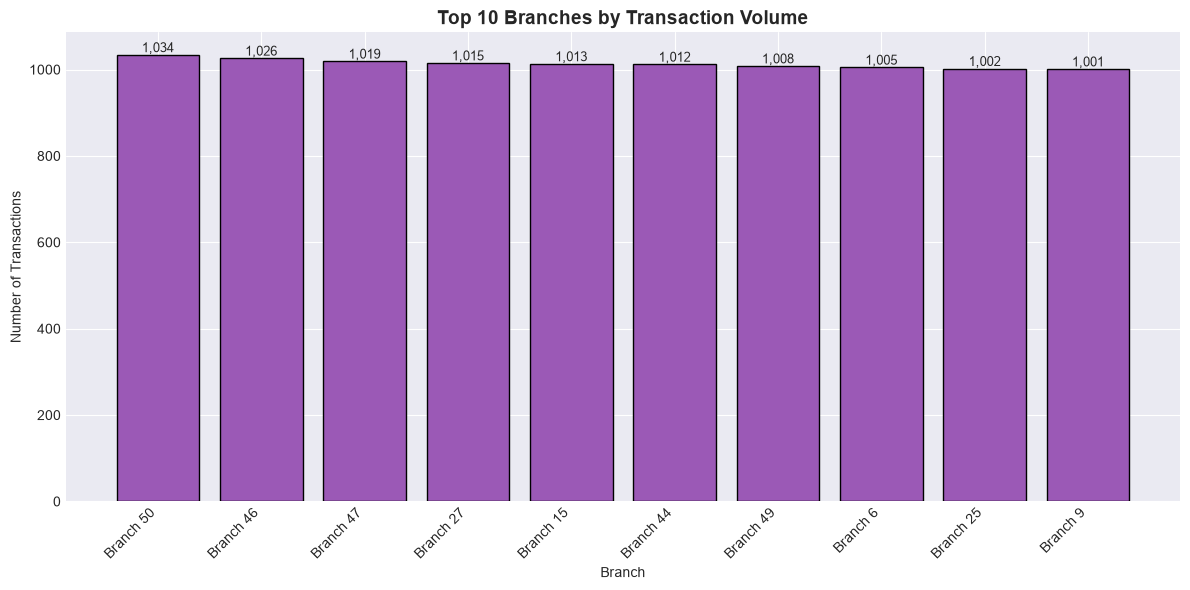

In [20]:
print("\n" + "="*80)
print("🏛️ QUESTION 5: What are the branch patterns?")
print("="*80)

if 'BranchName' in df_trans.columns:
    # Top branches by transaction count
    top_branches = df_trans['BranchName'].value_counts().head(10)
    print(f"\n📊 Top 10 Branches by Transaction Volume:")
    for branch, count in top_branches.items():
        pct = (count / len(df_trans)) * 100
        print(f"   {branch}: {count:,} ({pct:.1f}%)")
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(top_branches.index, top_branches.values, color='#9b59b6', edgecolor='black')
    plt.title('Top 10 Branches by Transaction Volume', fontsize=14, fontweight='bold')
    plt.xlabel('Branch')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=45, ha='right')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

In [22]:
print("\n" + "="*80)
print("✅ UNIVARIATE ANALYSIS COMPLETED!")
print("="*80)
print("\n📌 Key Takeaways:")
print("   • Fraud is imbalanced - need to handle class imbalance")
print("   • Transaction amounts are right-skewed - consider log transform")
print("   • Customer types are mostly individuals")
print("   • Most accounts are active")
print("   • Some branches handle more transactions than others")


print("="*80)


✅ UNIVARIATE ANALYSIS COMPLETED!

📌 Key Takeaways:
   • Fraud is imbalanced - need to handle class imbalance
   • Transaction amounts are right-skewed - consider log transform
   • Customer types are mostly individuals
   • Most accounts are active
   • Some branches handle more transactions than others


# BIVARIATE ANALYSIS


💸 QUESTION 1: How does transaction amount vary by type?

📊 Transaction Amount Statistics by Type:
               Mean   Median      Std   Min      Max  Count
TypeName                                                   
Deposit     2501.60  2509.15  1442.68  1.01  4999.37  14760
Payment     2499.56  2490.25  1452.86  1.74  4999.15   4860
Transfer    2516.90  2512.65  1442.82  1.20  4999.59  14478
Withdrawal  2495.99  2495.42  1438.33  1.92  4999.47  14412


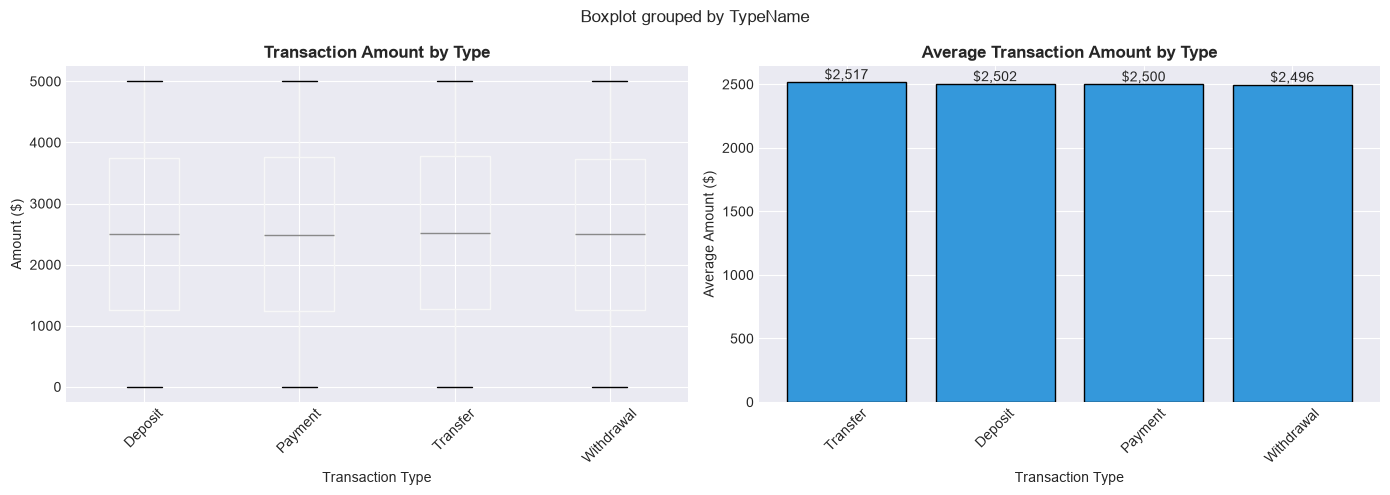


📊 ANOVA Test: Are amounts significantly different by type?
   F-statistic: 0.5624
   P-value: 0.6398
   ❌ No significant difference found.


In [24]:
from scipy import stats
print("\n" + "="*80)
print("💸 QUESTION 1: How does transaction amount vary by type?")
print("="*80)

if 'TypeName' in df_trans.columns and 'Amount' in df_trans.columns:
    # Group by transaction type
    type_stats = df_trans.groupby('TypeName')['Amount'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)
    type_stats.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Count']
    print("\n📊 Transaction Amount Statistics by Type:")
    print(type_stats)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot
    df_trans.boxplot(column='Amount', by='TypeName', ax=axes[0])
    axes[0].set_title('Transaction Amount by Type', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Transaction Type')
    axes[0].set_ylabel('Amount ($)')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Bar chart - average amount by type
    avg_by_type = df_trans.groupby('TypeName')['Amount'].mean().sort_values(ascending=False)
    bars = axes[1].bar(avg_by_type.index, avg_by_type.values, color='#3498db', edgecolor='black')
    axes[1].set_title('Average Transaction Amount by Type', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Transaction Type')
    axes[1].set_ylabel('Average Amount ($)')
    axes[1].tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:,.0f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical test: ANOVA
    groups = [df_trans[df_trans['TypeName'] == t]['Amount'].values for t in df_trans['TypeName'].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n📊 ANOVA Test: Are amounts significantly different by type?")
    print(f"   F-statistic: {f_stat:.4f}")
    print(f"   P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("   ✅ Significant difference found! Transaction type affects amount.")
    else:
        print("   ❌ No significant difference found.")


💰 QUESTION 2: How does account balance relate to transaction activity?

📊 Relationship between Account Balance and Transaction Count:
   Correlation: -0.0101

📊 Transaction Count by Balance Category:
                   Mean  Median   Std
Balance_Category                     
Low               29.57    29.0  6.03
Medium-Low        29.17    29.0  5.46
Medium-High       29.54    29.0  6.76
High              29.26    29.0  5.87


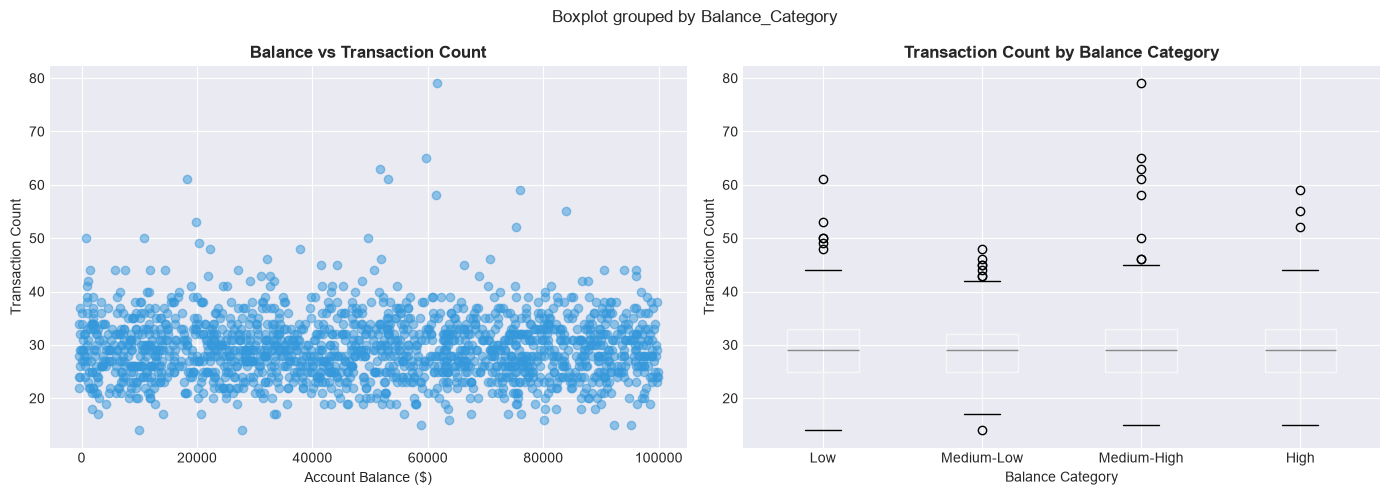

In [25]:
print("\n" + "="*80)
print("💰 QUESTION 2: How does account balance relate to transaction activity?")
print("="*80)

if 'Balance' in df_acc.columns and 'TransactionCount' in df_acc.columns:
    print("\n📊 Relationship between Account Balance and Transaction Count:")
    print(f"   Correlation: {df_acc['Balance'].corr(df_acc['TransactionCount']):.4f}")
    
    # Create balance categories
    df_acc['Balance_Category'] = pd.qcut(df_acc['Balance'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    
    print("\n📊 Transaction Count by Balance Category:")
    balance_stats = df_acc.groupby('Balance_Category')['TransactionCount'].agg(['mean', 'median', 'std']).round(2)
    balance_stats.columns = ['Mean', 'Median', 'Std']
    print(balance_stats)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(df_acc['Balance'], df_acc['TransactionCount'], alpha=0.5, color='#3498db')
    axes[0].set_title('Balance vs Transaction Count', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Account Balance ($)')
    axes[0].set_ylabel('Transaction Count')
    
    # Boxplot by balance category
    df_acc.boxplot(column='TransactionCount', by='Balance_Category', ax=axes[1])
    axes[1].set_title('Transaction Count by Balance Category', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Balance Category')
    axes[1].set_ylabel('Transaction Count')
    
    plt.tight_layout()
    plt.show()


👤 QUESTION 3: How does customer type affect account behavior?

📊 Customer Type vs Total Balance:
                  Mean Balance  Median Balance       Std  Count
TypeName                                                       
Individual            73822.80        66553.69  68778.96    351
Large Enterprise      72061.50        60268.80  66120.19    397
Small Business        75331.71        57407.97  80279.42    352


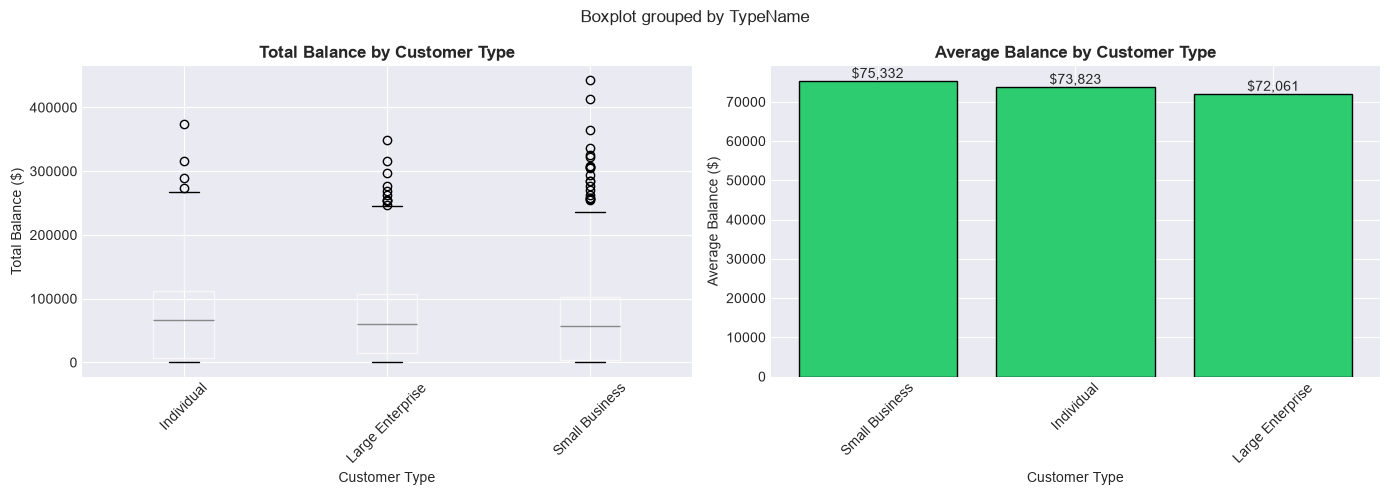

In [26]:
print("\n" + "="*80)
print("👤 QUESTION 3: How does customer type affect account behavior?")
print("="*80)

if 'TypeName' in df_cust.columns and 'TotalBalance' in df_cust.columns:
    print("\n📊 Customer Type vs Total Balance:")
    cust_balance = df_cust.groupby('TypeName')['TotalBalance'].agg(['mean', 'median', 'std', 'count']).round(2)
    cust_balance.columns = ['Mean Balance', 'Median Balance', 'Std', 'Count']
    print(cust_balance)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot
    df_cust.boxplot(column='TotalBalance', by='TypeName', ax=axes[0])
    axes[0].set_title('Total Balance by Customer Type', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Customer Type')
    axes[0].set_ylabel('Total Balance ($)')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Bar chart - average balance
    avg_balance = df_cust.groupby('TypeName')['TotalBalance'].mean().sort_values(ascending=False)
    bars = axes[1].bar(avg_balance.index, avg_balance.values, color='#2ecc71', edgecolor='black')
    axes[1].set_title('Average Balance by Customer Type', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Customer Type')
    axes[1].set_ylabel('Average Balance ($)')
    axes[1].tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:,.0f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()


🏠 QUESTION 4: How do loan characteristics vary by loan status?

📊 Loan Amount by Status:
                  Mean    Median       Std  Count
LoanStatusID                                     
1             51945.16  52436.38  28985.57    239
2             52664.97  47361.17  29138.87     57
3             49135.81  52482.45  24860.18     34


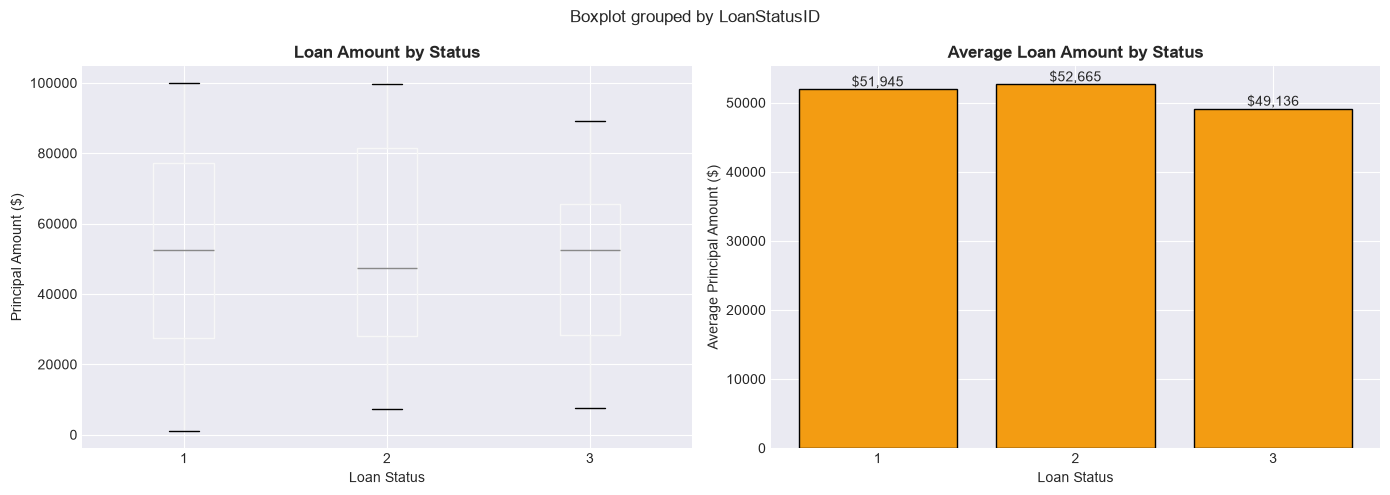


📊 Interest Rate by Status:
                Mean  Median     Std
LoanStatusID                        
1             0.0917  0.0940  0.0318
2             0.0850  0.0846  0.0335
3             0.0811  0.0740  0.0366


<Figure size 1000x600 with 0 Axes>

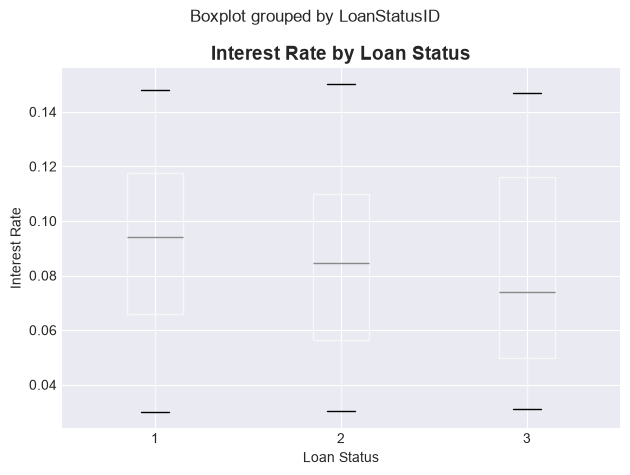

In [27]:
print("\n" + "="*80)
print("🏠 QUESTION 4: How do loan characteristics vary by loan status?")
print("="*80)

try:
    # Try to load loans data
    df_loans = pd.read_csv('../data/processed/loans.csv')
    
    if 'LoanStatusID' in df_loans.columns:
        print("\n📊 Loan Amount by Status:")
        loan_stats = df_loans.groupby('LoanStatusID')['PrincipalAmount'].agg(['mean', 'median', 'std', 'count']).round(2)
        loan_stats.columns = ['Mean', 'Median', 'Std', 'Count']
        print(loan_stats)
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Boxplot
        df_loans.boxplot(column='PrincipalAmount', by='LoanStatusID', ax=axes[0])
        axes[0].set_title('Loan Amount by Status', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Loan Status')
        axes[0].set_ylabel('Principal Amount ($)')
        
        # Bar chart
        avg_loan = df_loans.groupby('LoanStatusID')['PrincipalAmount'].mean()
        bars = axes[1].bar(avg_loan.index.astype(str), avg_loan.values, color='#f39c12', edgecolor='black')
        axes[1].set_title('Average Loan Amount by Status', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Loan Status')
        axes[1].set_ylabel('Average Principal Amount ($)')
        for bar in bars:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'${height:,.0f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Interest rate by status
        print("\n📊 Interest Rate by Status:")
        rate_stats = df_loans.groupby('LoanStatusID')['InterestRate'].agg(['mean', 'median', 'std']).round(4)
        rate_stats.columns = ['Mean', 'Median', 'Std']
        print(rate_stats)
        
        plt.figure(figsize=(10, 6))
        df_loans.boxplot(column='InterestRate', by='LoanStatusID')
        plt.title('Interest Rate by Loan Status', fontsize=14, fontweight='bold')
        plt.xlabel('Loan Status')
        plt.ylabel('Interest Rate')
        plt.tight_layout()
        plt.show()
except:
    print("\n⚠️ Loan data not available for analysis")


🏛️ QUESTION 5: How do branches compare in transaction volume and amounts?


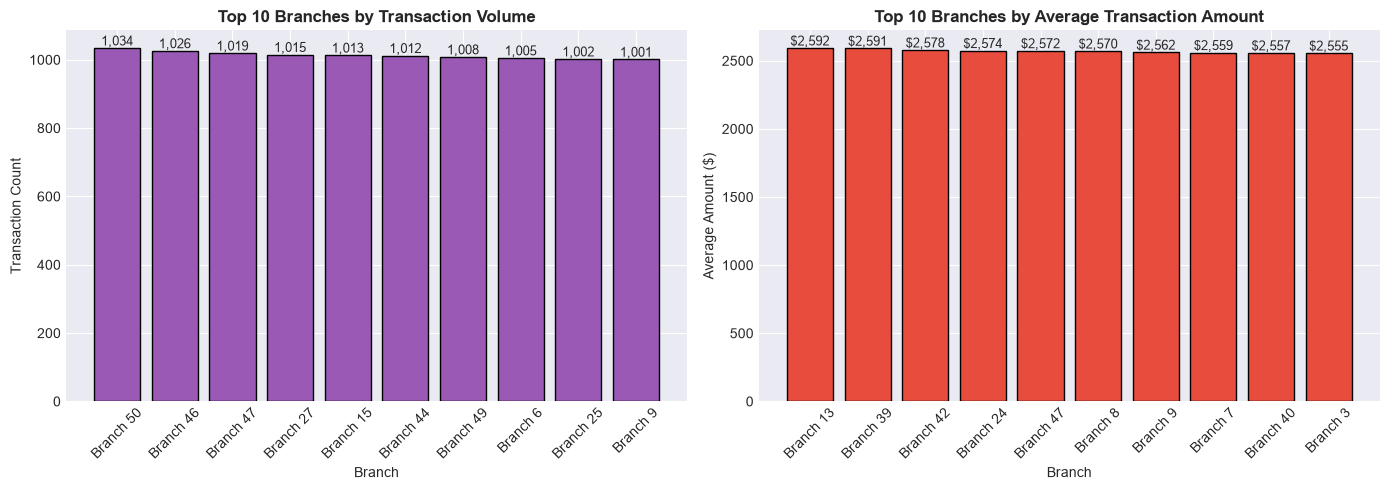

In [28]:
print("\n" + "="*80)
print("🏛️ QUESTION 5: How do branches compare in transaction volume and amounts?")
print("="*80)

if 'BranchName' in df_trans.columns:
    # Top 10 branches by transaction count
    branch_volume = df_trans['BranchName'].value_counts().head(10)
    
    # Average amount per branch
    branch_avg = df_trans.groupby('BranchName')['Amount'].mean().sort_values(ascending=False).head(10)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Volume by branch
    bars = axes[0].bar(branch_volume.index, branch_volume.values, color='#9b59b6', edgecolor='black')
    axes[0].set_title('Top 10 Branches by Transaction Volume', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Branch')
    axes[0].set_ylabel('Transaction Count')
    axes[0].tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=9)
    
    # Average amount by branch
    bars = axes[1].bar(branch_avg.index, branch_avg.values, color='#e74c3c', edgecolor='black')
    axes[1].set_title('Top 10 Branches by Average Transaction Amount', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Branch')
    axes[1].set_ylabel('Average Amount ($)')
    axes[1].tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:,.0f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()


📅 QUESTION 6: Are there seasonal patterns in transactions?


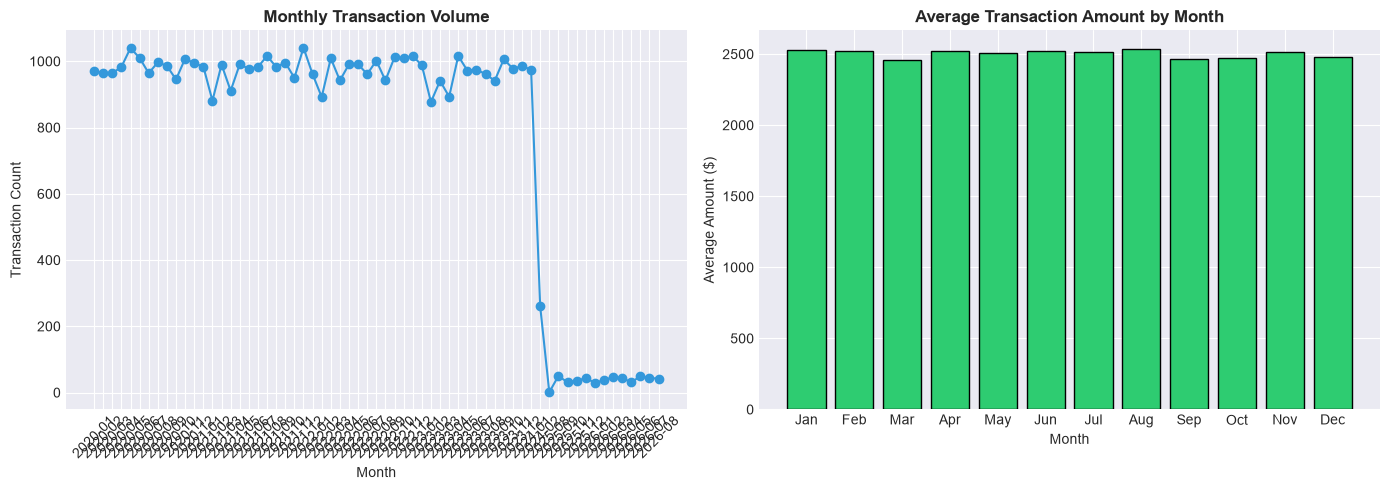

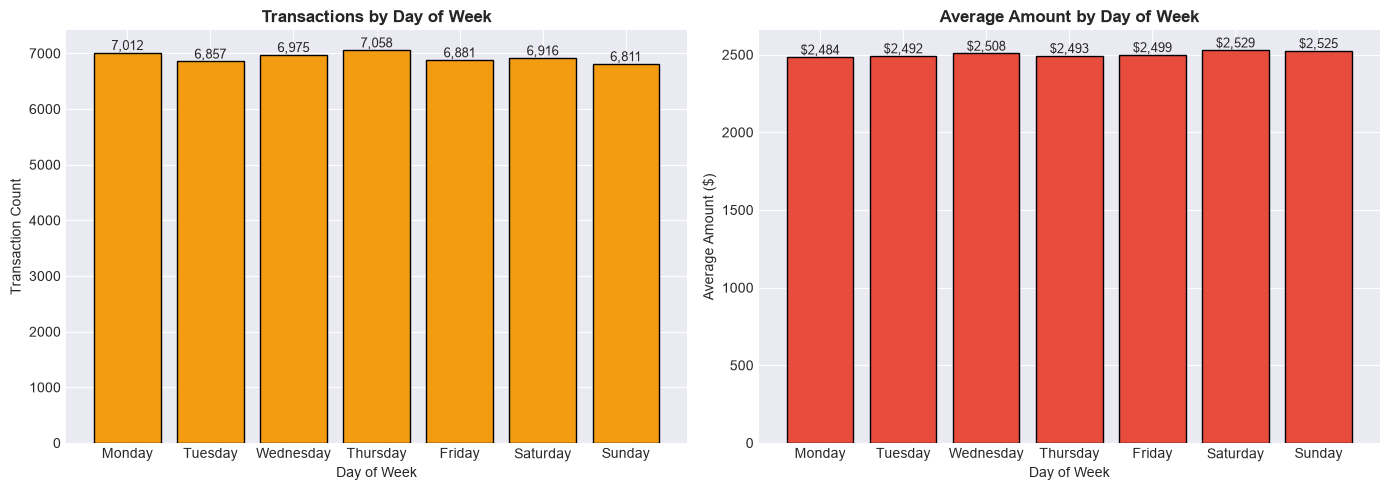

In [29]:
print("\n" + "="*80)
print("📅 QUESTION 6: Are there seasonal patterns in transactions?")
print("="*80)

if 'TransactionDate' in df_trans.columns:
    # Convert to datetime if needed
    df_trans['TransactionDate'] = pd.to_datetime(df_trans['TransactionDate'])
    
    # Extract month and year
    df_trans['Month'] = df_trans['TransactionDate'].dt.month
    df_trans['Year'] = df_trans['TransactionDate'].dt.year
    df_trans['DayOfWeek'] = df_trans['TransactionDate'].dt.day_name()
    
    # Monthly transaction volume
    monthly_volume = df_trans.groupby(['Year', 'Month']).size().reset_index(name='Count')
    monthly_amount = df_trans.groupby(['Year', 'Month'])['Amount'].mean().reset_index(name='Avg_Amount')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Monthly volume
    monthly_volume['YearMonth'] = monthly_volume['Year'].astype(str) + '-' + monthly_volume['Month'].astype(str).str.zfill(2)
    axes[0].plot(monthly_volume['YearMonth'], monthly_volume['Count'], marker='o', color='#3498db')
    axes[0].set_title('Monthly Transaction Volume', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Transaction Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Average amount by month
    monthly_avg = df_trans.groupby('Month')['Amount'].mean()
    axes[1].bar(monthly_avg.index, monthly_avg.values, color='#2ecc71', edgecolor='black')
    axes[1].set_title('Average Transaction Amount by Month', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Average Amount ($)')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    plt.tight_layout()
    plt.show()
    
    # Day of week patterns
    dow_volume = df_trans['DayOfWeek'].value_counts()
    dow_amount = df_trans.groupby('DayOfWeek')['Amount'].mean()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Volume by day
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_volume = dow_volume.reindex(day_order)
    bars = axes[0].bar(dow_volume.index, dow_volume.values, color='#f39c12', edgecolor='black')
    axes[0].set_title('Transactions by Day of Week', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Day of Week')
    axes[0].set_ylabel('Transaction Count')
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=9)
    
    # Average amount by day
    dow_amount = dow_amount.reindex(day_order)
    bars = axes[1].bar(dow_amount.index, dow_amount.values, color='#e74c3c', edgecolor='black')
    axes[1].set_title('Average Amount by Day of Week', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Average Amount ($)')
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:,.0f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n" + "="*80)
print("✅ BIVARIATE ANALYSIS COMPLETED!")
print("="*80)
print("\n📌 Key Takeaways:")
print("   • Transaction amounts vary significantly by type")
print("   • Account balance correlates with transaction activity")
print("   • Customer type affects account behavior")
print("   • Branches show different performance patterns")
print("   • There are seasonal patterns in transactions")


print("="*80)


✅ BIVARIATE ANALYSIS COMPLETED!

📌 Key Takeaways:
   • Transaction amounts vary significantly by type
   • Account balance correlates with transaction activity
   • Customer type affects account behavior
   • Branches show different performance patterns
   • There are seasonal patterns in transactions

➡️ Ready for Multivariate Analysis? Let me know!


# MULTIVARIATE ANALYSIS


💸 QUESTION 1: How do amount, type, and branch interact?

📊 Average Transaction Amount by Type and Branch:
BranchName    Branch 50    Branch 46    Branch 47    Branch 27    Branch 15
TypeName                                                                   
Deposit     2490.040204  2454.997315  2466.139361  2398.712797  2477.770662
Payment     2633.458898  2574.571810  2387.691957  2338.373391  2495.460164
Transfer    2306.463355  2532.125098  2536.152755  2627.186164  2498.724521
Withdrawal  2495.881133  2461.227634  2785.461031  2453.146486  2439.132359


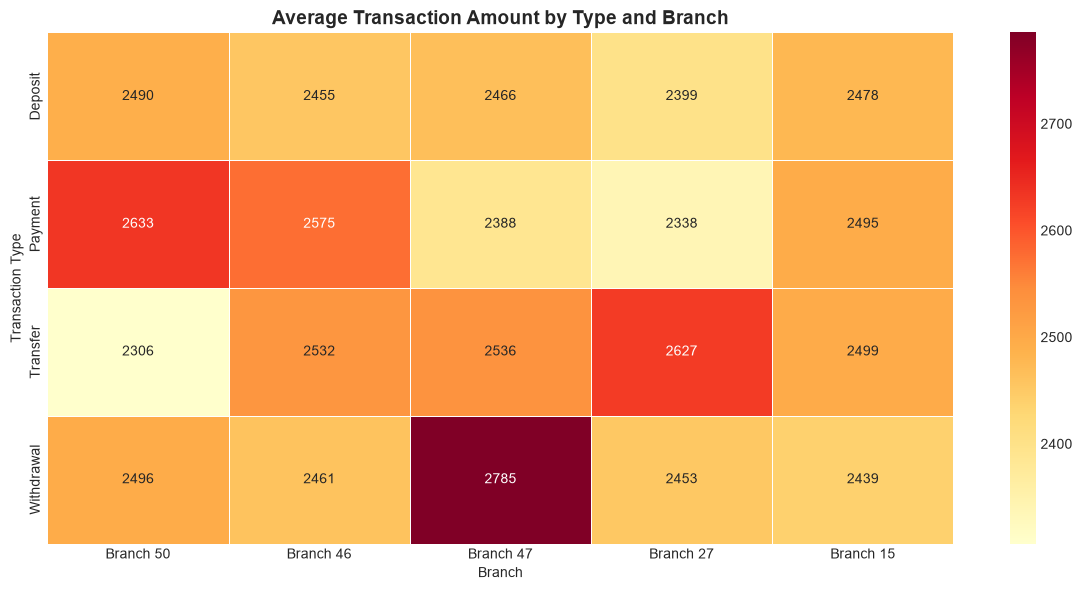

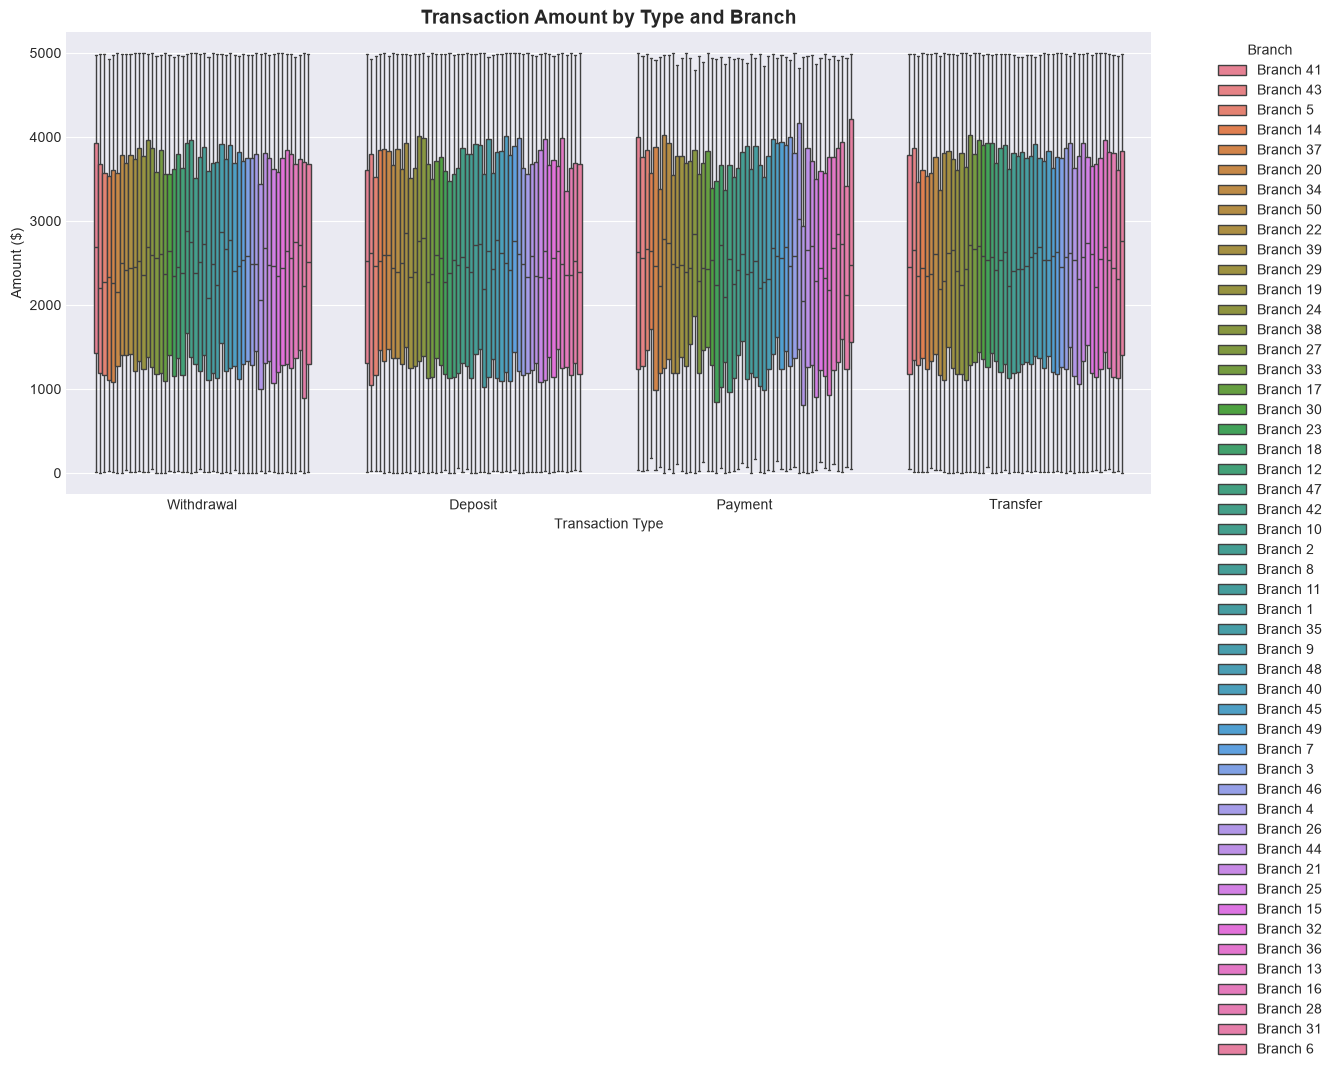

In [31]:
print("\n" + "="*80)
print("💸 QUESTION 1: How do amount, type, and branch interact?")
print("="*80)

if all(col in df_trans.columns for col in ['Amount', 'TypeName', 'BranchName']):
    # Create a pivot table of average amount by type and branch
    pivot_data = df_trans.pivot_table(
        values='Amount',
        index='TypeName',
        columns='BranchName',
        aggfunc='mean'
    ).fillna(0)
    
    # Show top branches for clarity
    top_branches = df_trans['BranchName'].value_counts().head(5).index
    pivot_data = pivot_data[top_branches]
    
    print("\n📊 Average Transaction Amount by Type and Branch:")
    print(pivot_data)
    
    # Heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Average Transaction Amount by Type and Branch', fontsize=14, fontweight='bold')
    plt.xlabel('Branch')
    plt.ylabel('Transaction Type')
    plt.tight_layout()
    plt.show()
    
    # Boxplot showing interaction
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_trans, x='TypeName', y='Amount', hue='BranchName')
    plt.title('Transaction Amount by Type and Branch', fontsize=14, fontweight='bold')
    plt.xlabel('Transaction Type')
    plt.ylabel('Amount ($)')
    plt.legend(title='Branch', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


💰 QUESTION 2: How do balance, transaction count, and account type relate?

📊 Transaction Count by Account Type and Balance Category:
                           Mean_Transactions  Median_Transactions  Count
TypeName Balance_Category                                               
Business Low                           30.01                 29.0    104
         Medium-Low                    29.62                 30.0     76
         Medium-High                   30.57                 30.0     89
         High                          29.35                 29.0     91
Checking Low                           29.42                 29.0     79
         Medium-Low                    30.10                 29.0     77
         Medium-High                   29.40                 29.0     86
         High                          29.71                 31.0     69
Payroll  Low                           29.76                 29.0     70
         Medium-Low                    29.10                 29

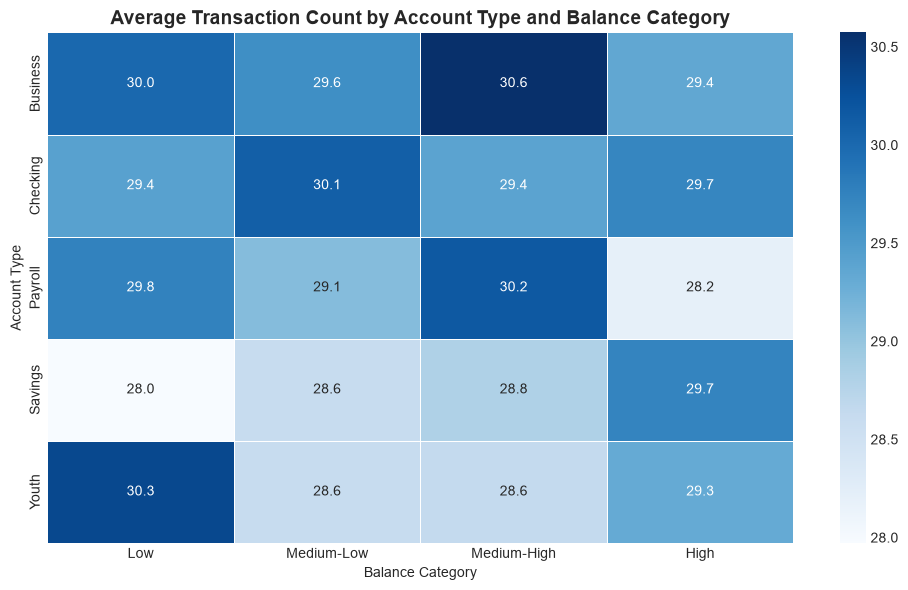

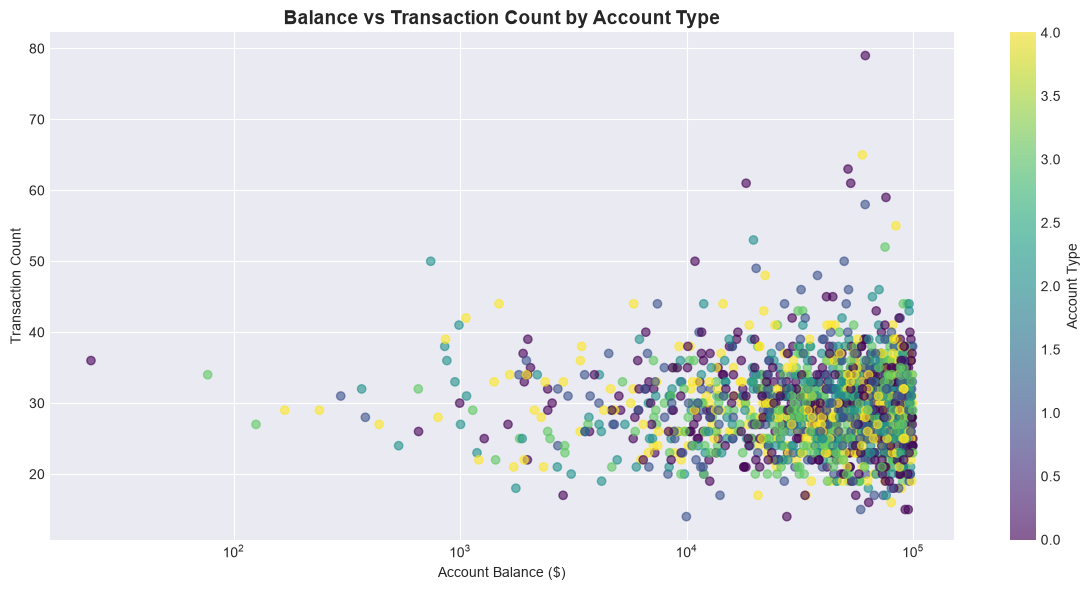

In [32]:
print("\n" + "="*80)
print("💰 QUESTION 2: How do balance, transaction count, and account type relate?")
print("="*80)

if all(col in df_acc.columns for col in ['Balance', 'TransactionCount', 'TypeName']):
    # Create balance categories
    df_acc['Balance_Category'] = pd.qcut(df_acc['Balance'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    
    # Group by account type and balance category
    grouped = df_acc.groupby(['TypeName', 'Balance_Category'])['TransactionCount'].agg(['mean', 'median', 'count']).round(2)
    grouped.columns = ['Mean_Transactions', 'Median_Transactions', 'Count']
    print("\n📊 Transaction Count by Account Type and Balance Category:")
    print(grouped)
    
    # Heatmap of mean transactions
    pivot_trans = df_acc.pivot_table(
        values='TransactionCount',
        index='TypeName',
        columns='Balance_Category',
        aggfunc='mean'
    ).fillna(0)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_trans, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
    plt.title('Average Transaction Count by Account Type and Balance Category', fontsize=14, fontweight='bold')
    plt.xlabel('Balance Category')
    plt.ylabel('Account Type')
    plt.tight_layout()
    plt.show()
    
    # Scatter plot with colors by account type
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(
        df_acc['Balance'],
        df_acc['TransactionCount'],
        c=df_acc['TypeName'].astype('category').cat.codes,
        alpha=0.6,
        cmap='viridis'
    )
    plt.colorbar(scatter, label='Account Type')
    plt.title('Balance vs Transaction Count by Account Type', fontsize=14, fontweight='bold')
    plt.xlabel('Account Balance ($)')
    plt.ylabel('Transaction Count')
    plt.xscale('log')
    plt.tight_layout()
    plt.show()


👤 QUESTION 3: How do customer type, account count, and total balance relate?

📊 Total Balance by Customer Type and Account Count:
                                   Mean_Balance  Median_Balance  Count
TypeName         Account_Category                                     
Individual       1 Account             49191.21        51081.13    112
                 2-3 Accounts         116491.56       111718.32    143
                 4-5 Accounts         220240.79       220393.92     17
Large Enterprise 1 Account             46958.72        42064.37    141
                 2-3 Accounts         108743.35       105502.08    161
                 4-5 Accounts         199669.06       182024.08     20
                 6+ Accounts          243086.49       243086.49      2
Small Business   1 Account             52997.89        54847.90    124
                 2-3 Accounts         112518.12       107620.11    113
                 4-5 Accounts         226745.33       245128.27     22
                 

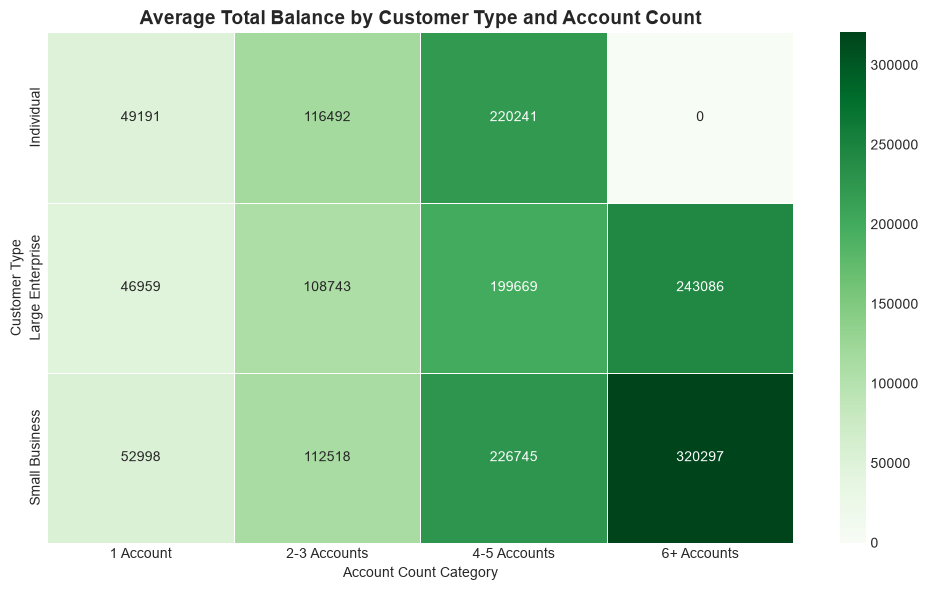

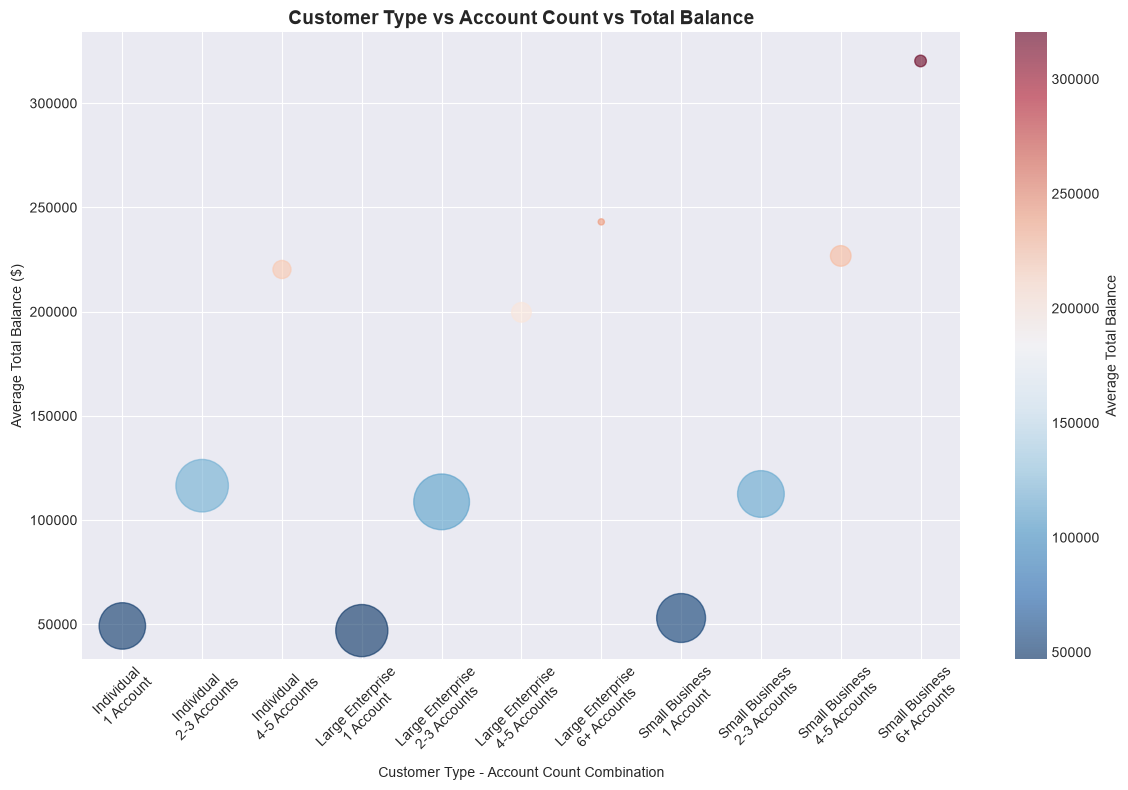

In [33]:
print("\n" + "="*80)
print("👤 QUESTION 3: How do customer type, account count, and total balance relate?")
print("="*80)

if all(col in df_cust.columns for col in ['TypeName', 'AccountCount', 'TotalBalance']):
    # Create account count categories
    df_cust['Account_Category'] = pd.cut(
        df_cust['AccountCount'],
        bins=[0, 1, 3, 5, 10],
        labels=['1 Account', '2-3 Accounts', '4-5 Accounts', '6+ Accounts']
    )
    
    # Group by customer type and account category
    grouped = df_cust.groupby(['TypeName', 'Account_Category'])['TotalBalance'].agg(['mean', 'median', 'count']).round(2)
    grouped.columns = ['Mean_Balance', 'Median_Balance', 'Count']
    print("\n📊 Total Balance by Customer Type and Account Count:")
    print(grouped)
    
    # Heatmap
    pivot_balance = df_cust.pivot_table(
        values='TotalBalance',
        index='TypeName',
        columns='Account_Category',
        aggfunc='mean'
    ).fillna(0)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_balance, annot=True, fmt='.0f', cmap='Greens', linewidths=0.5)
    plt.title('Average Total Balance by Customer Type and Account Count', fontsize=14, fontweight='bold')
    plt.xlabel('Account Count Category')
    plt.ylabel('Customer Type')
    plt.tight_layout()
    plt.show()
    
    # Bubble chart
    plt.figure(figsize=(12, 8))
    
    # Calculate size (count of customers) and color (total balance)
    sizes = df_cust.groupby(['TypeName', 'Account_Category']).size()
    balances = df_cust.groupby(['TypeName', 'Account_Category'])['TotalBalance'].mean()
    
    # Prepare data for bubble chart
    categories = sizes.index
    x_pos = range(len(categories))
    
    # Convert to list for plotting
    sizes_list = sizes.values * 10  # Scale for visibility
    colors_list = balances.values
    
    scatter = plt.scatter(
        x_pos,
        balances.values,
        s=sizes_list,
        c=colors_list,
        alpha=0.6,
        cmap='RdBu_r'
    )
    
    plt.colorbar(scatter, label='Average Total Balance')
    plt.title('Customer Type vs Account Count vs Total Balance', fontsize=14, fontweight='bold')
    plt.xlabel('Customer Type - Account Count Combination')
    plt.ylabel('Average Total Balance ($)')
    plt.xticks(x_pos, [f'{c[0]}\n{c[1]}' for c in categories], rotation=45)
    plt.tight_layout()
    plt.show()


🏠 QUESTION 4: How do loan amount, interest rate, and status relate?

📊 Loan Amount and Interest Rate by Status:
              Amount_Mean  Amount_Median  Amount_Std  Rate_Mean  Rate_Median  \
LoanStatusID                                                                   
1                51945.16       52436.38    28985.57       0.09         0.09   
2                52664.97       47361.17    29138.87       0.09         0.08   
3                49135.81       52482.45    24860.18       0.08         0.07   

              Rate_Std  Count  
LoanStatusID                   
1                 0.03    239  
2                 0.03     57  
3                 0.04     34  


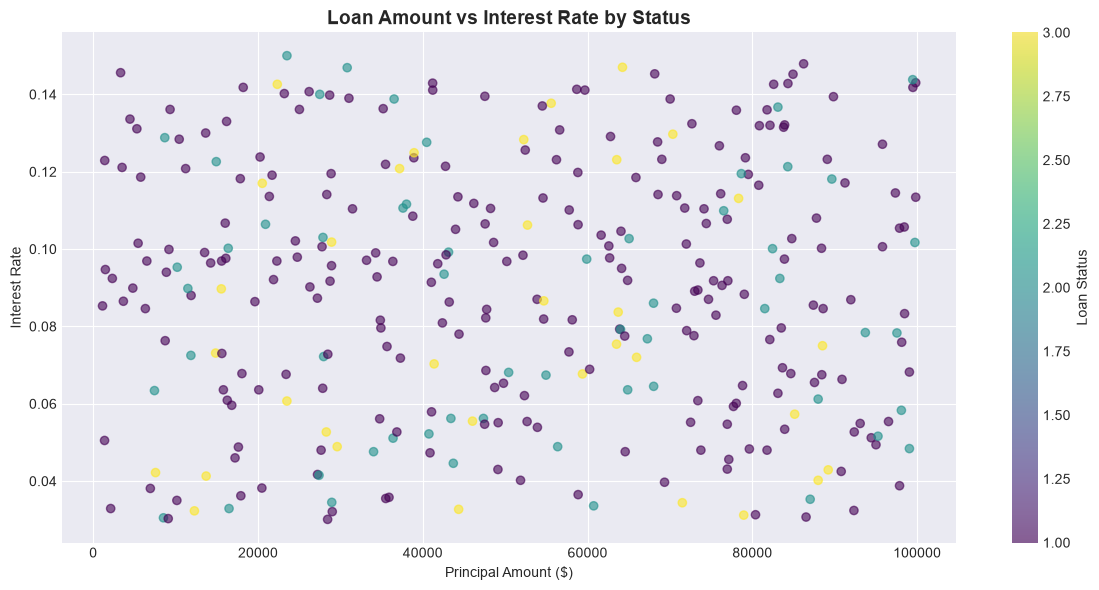

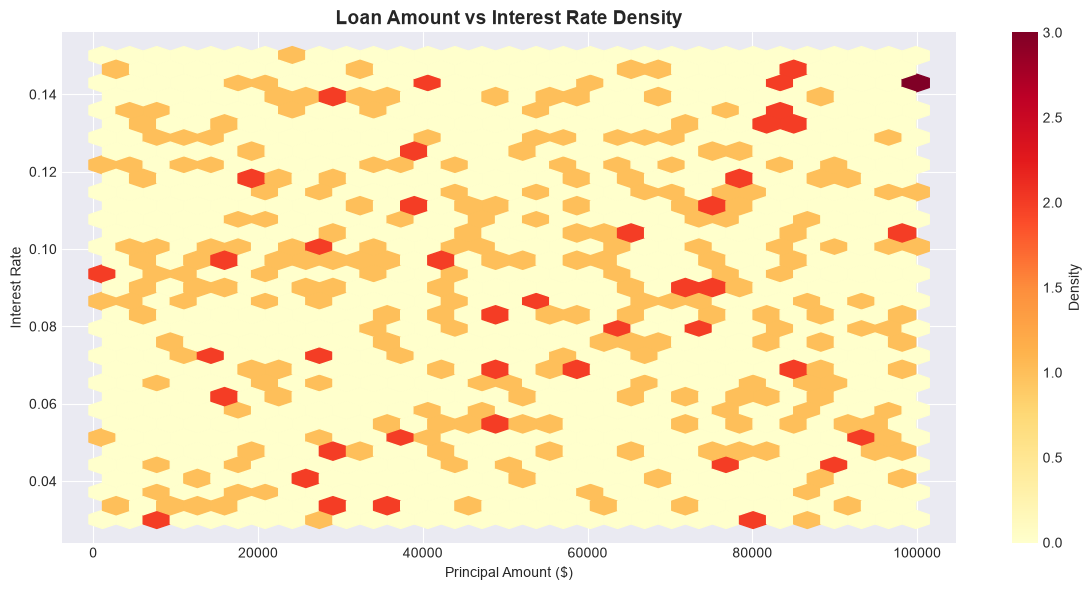

In [34]:
print("\n" + "="*80)
print("🏠 QUESTION 4: How do loan amount, interest rate, and status relate?")
print("="*80)

try:
    df_loans = pd.read_csv('../data/processed/loans.csv')
    
    if all(col in df_loans.columns for col in ['PrincipalAmount', 'InterestRate', 'LoanStatusID']):
        # Group by status
        grouped = df_loans.groupby('LoanStatusID').agg({
            'PrincipalAmount': ['mean', 'median', 'std'],
            'InterestRate': ['mean', 'median', 'std'],
            'LoanID': 'count'
        }).round(2)
        grouped.columns = ['Amount_Mean', 'Amount_Median', 'Amount_Std', 
                          'Rate_Mean', 'Rate_Median', 'Rate_Std', 'Count']
        print("\n📊 Loan Amount and Interest Rate by Status:")
        print(grouped)
        
        # Scatter plot with colors by status
        plt.figure(figsize=(12, 6))
        scatter = plt.scatter(
            df_loans['PrincipalAmount'],
            df_loans['InterestRate'],
            c=df_loans['LoanStatusID'],
            alpha=0.6,
            cmap='viridis'
        )
        plt.colorbar(scatter, label='Loan Status')
        plt.title('Loan Amount vs Interest Rate by Status', fontsize=14, fontweight='bold')
        plt.xlabel('Principal Amount ($)')
        plt.ylabel('Interest Rate')
        plt.tight_layout()
        plt.show()
        
        # Hexbin plot for density
        plt.figure(figsize=(12, 6))
        plt.hexbin(df_loans['PrincipalAmount'], df_loans['InterestRate'], gridsize=30, cmap='YlOrRd')
        plt.colorbar(label='Density')
        plt.title('Loan Amount vs Interest Rate Density', fontsize=14, fontweight='bold')
        plt.xlabel('Principal Amount ($)')
        plt.ylabel('Interest Rate')
        plt.tight_layout()
        plt.show()
except:
    print("\n⚠️ Loan data not available")


💸 QUESTION 5: How do transaction amount, type, and customer type relate?

📊 Transaction Amount by Type and Customer Type:
                             Mean_Amount  Median_Amount  Count
TypeName   CustomerType                                       
Deposit    Individual            2496.64        2516.76   4474
           Large Enterprise      2493.71        2489.14   5534
           Small Business        2515.46        2524.29   4752
Payment    Individual            2523.58        2540.53   1477
           Large Enterprise      2466.69        2412.75   1837
           Small Business        2515.67        2545.35   1546
Transfer   Individual            2476.22        2448.64   4428
           Large Enterprise      2526.89        2542.40   5347
           Small Business        2543.84        2547.22   4703
Withdrawal Individual            2502.21        2504.14   4456
           Large Enterprise      2490.27        2499.15   5377
           Small Business        2496.65        2480.82   

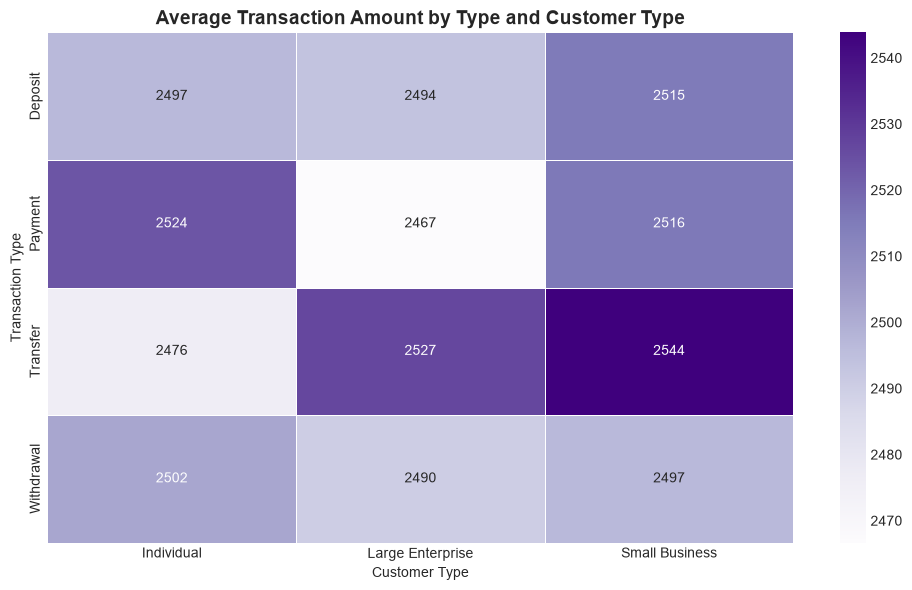

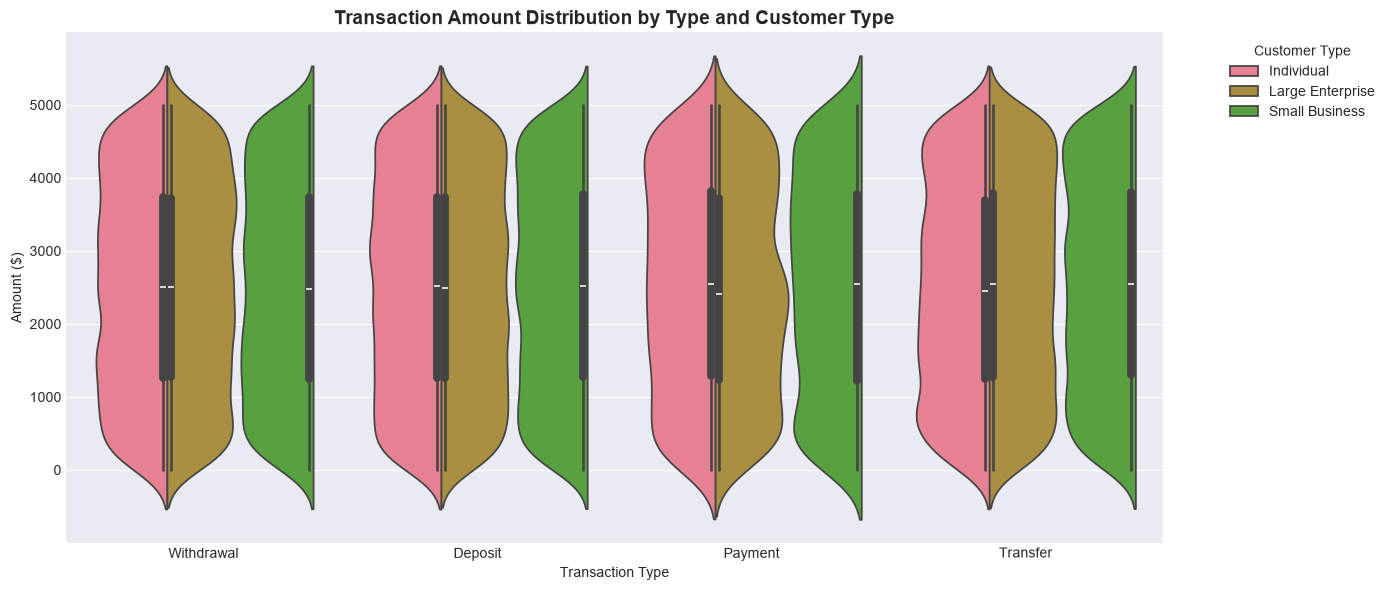

In [35]:
print("\n" + "="*80)
print("💸 QUESTION 5: How do transaction amount, type, and customer type relate?")
print("="*80)

if all(col in df_trans.columns for col in ['Amount', 'TypeName', 'OriginCustomerTypeID']):
    # Create customer type categories
    df_trans['CustomerType'] = df_trans['OriginCustomerTypeID'].map({
        1: 'Individual',
        2: 'Small Business',
        3: 'Large Enterprise'
    })
    
    # Group by transaction type and customer type
    grouped = df_trans.groupby(['TypeName', 'CustomerType'])['Amount'].agg(['mean', 'median', 'count']).round(2)
    grouped.columns = ['Mean_Amount', 'Median_Amount', 'Count']
    print("\n📊 Transaction Amount by Type and Customer Type:")
    print(grouped)
    
    # Heatmap
    pivot_amount = df_trans.pivot_table(
        values='Amount',
        index='TypeName',
        columns='CustomerType',
        aggfunc='mean'
    ).fillna(0)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_amount, annot=True, fmt='.0f', cmap='Purples', linewidths=0.5)
    plt.title('Average Transaction Amount by Type and Customer Type', fontsize=14, fontweight='bold')
    plt.xlabel('Customer Type')
    plt.ylabel('Transaction Type')
    plt.tight_layout()
    plt.show()
    
    # Violin plot
    plt.figure(figsize=(14, 6))
    sns.violinplot(data=df_trans, x='TypeName', y='Amount', hue='CustomerType', split=True)
    plt.title('Transaction Amount Distribution by Type and Customer Type', fontsize=14, fontweight='bold')
    plt.xlabel('Transaction Type')
    plt.ylabel('Amount ($)')
    plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


🔗 QUESTION 6: Overall correlation between all numerical features


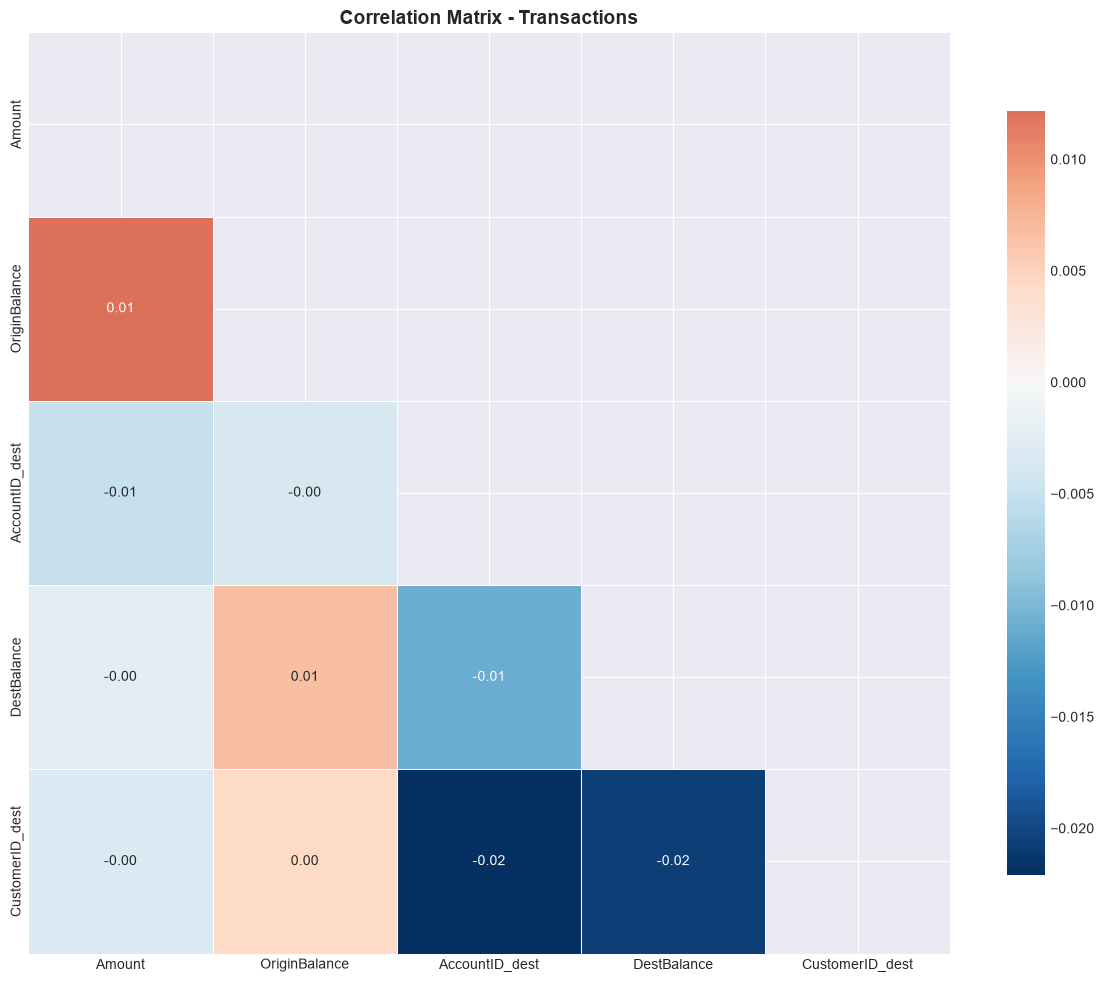


📊 Strong Correlations in Accounts (>0.5):
   • AvgInterestRate ↔ MaxInterestRate: 0.976
   • AvgPrincipal ↔ MaxPrincipal: 0.975
   • TotalPrincipal ↔ MaxPrincipal: 0.904
   • TransactionCount ↔ TotalTransactionAmount: 0.889
   • TotalPrincipal ↔ AvgPrincipal: 0.847
   • LoanCount ↔ TotalPrincipal: 0.517


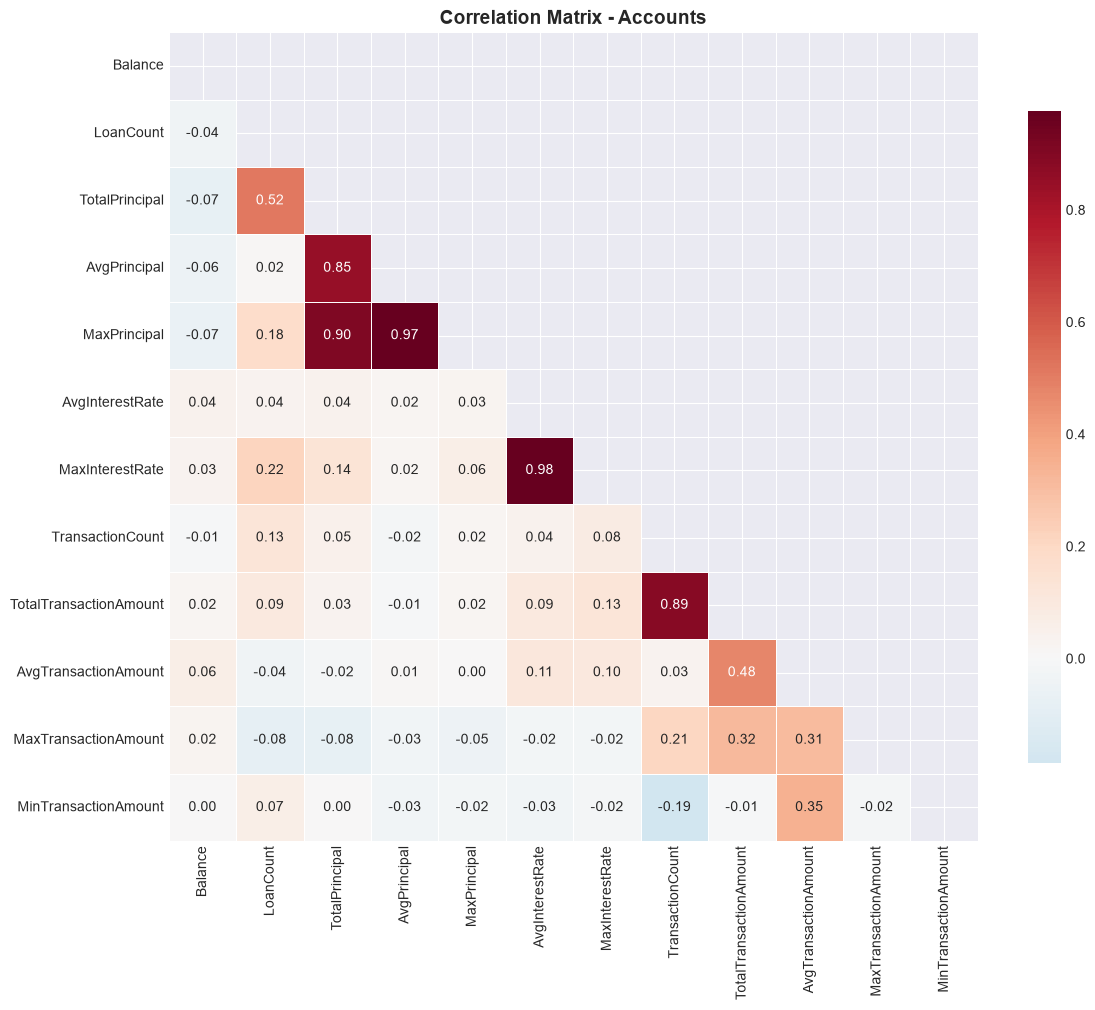


📊 Strong Correlations in Customers (>0.5):
   • CustomerAvgInterestRate ↔ CustomerMaxInterestRate: 0.994
   • CustomerAvgPrincipal ↔ CustomerMaxPrincipal: 0.985
   • CustomerTotalPrincipal ↔ CustomerMaxPrincipal: 0.949
   • AvgBalance ↔ MaxBalance: 0.928
   • CustomerTotalPrincipal ↔ CustomerAvgPrincipal: 0.909
   • CustomerLoanCount ↔ CustomerTotalPrincipal: 0.895
   • CustomerLoanCount ↔ CustomerMaxInterestRate: 0.878
   • AccountCount ↔ TotalBalance: 0.852
   • CustomerLoanCount ↔ CustomerMaxPrincipal: 0.843
   • CustomerLoanCount ↔ CustomerAvgInterestRate: 0.842
   • TotalBalance ↔ MaxBalance: 0.825
   • CustomerMaxPrincipal ↔ CustomerMaxInterestRate: 0.814
   • CustomerMaxPrincipal ↔ CustomerAvgInterestRate: 0.803
   • CustomerAvgPrincipal ↔ CustomerAvgInterestRate: 0.799
   • CustomerAvgPrincipal ↔ CustomerMaxInterestRate: 0.797
   • CustomerTotalPrincipal ↔ CustomerMaxInterestRate: 0.782
   • CustomerLoanCount ↔ CustomerAvgPrincipal: 0.779
   • CustomerTotalPrincipal ↔ Customer

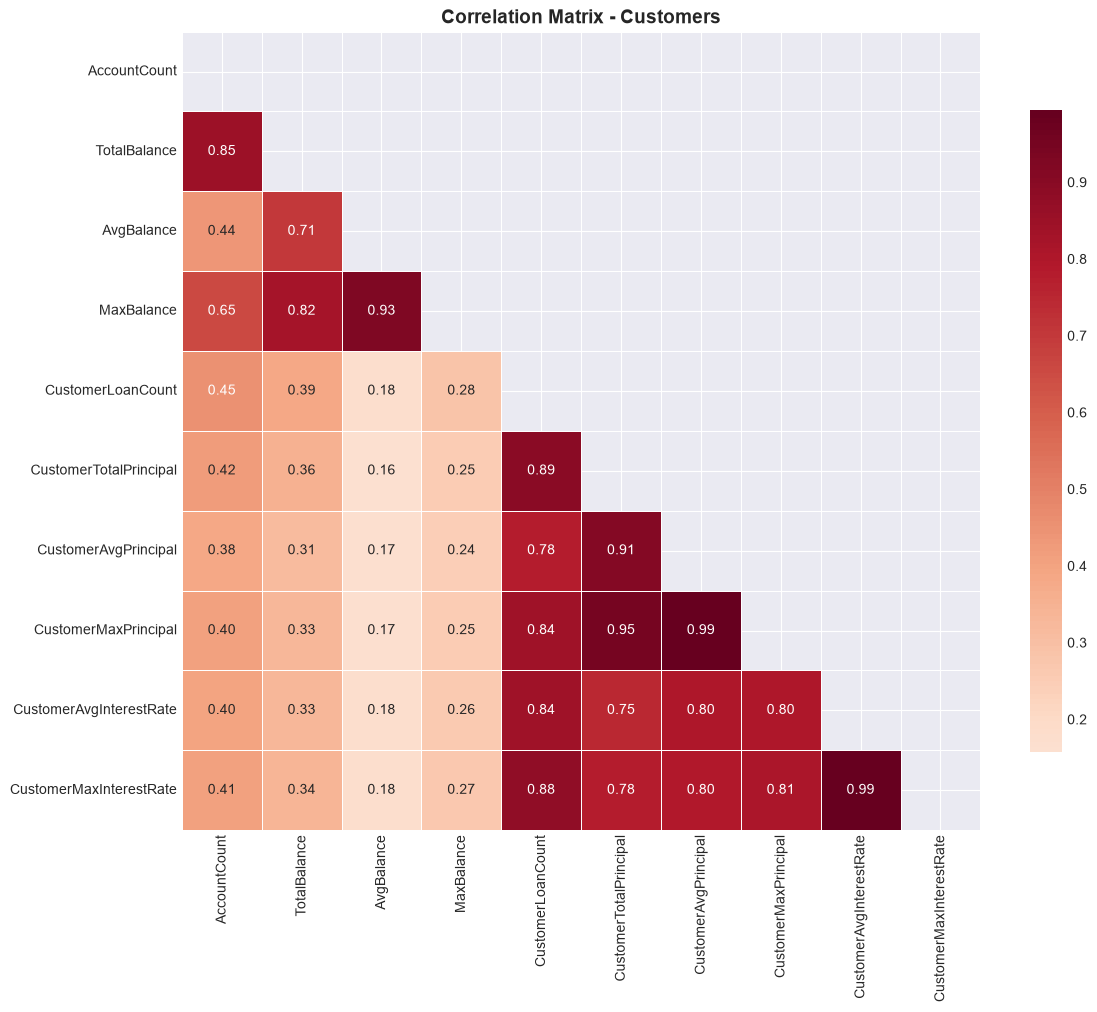

In [36]:
print("\n" + "="*80)
print("🔗 QUESTION 6: Overall correlation between all numerical features")
print("="*80)

# Function to create correlation matrix for a dataset
def plot_correlation_matrix(df, dataset_name, max_features=15):
    # Select numerical columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    # Remove ID columns
    num_cols = [col for col in num_cols if not col.endswith('ID')]
    # Limit to max_features
    num_cols = num_cols[:max_features]
    
    if len(num_cols) > 1:
        # Calculate correlation matrix
        corr_matrix = df[num_cols].corr()
        
        # Find strong correlations
        strong_corr = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.5:
                    strong_corr.append({
                        'Feature1': corr_matrix.columns[i],
                        'Feature2': corr_matrix.columns[j],
                        'Correlation': corr_matrix.iloc[i, j]
                    })
        
        if strong_corr:
            print(f"\n📊 Strong Correlations in {dataset_name} (>0.5):")
            for item in sorted(strong_corr, key=lambda x: abs(x['Correlation']), reverse=True):
                print(f"   • {item['Feature1']} ↔ {item['Feature2']}: {item['Correlation']:.3f}")
        
        # Plot heatmap
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8}
        )
        plt.title(f'Correlation Matrix - {dataset_name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Plot correlation matrices for each dataset
plot_correlation_matrix(df_trans, 'Transactions', max_features=15)
plot_correlation_matrix(df_acc, 'Accounts', max_features=15)
plot_correlation_matrix(df_cust, 'Customers', max_features=15)


📅 QUESTION 7: How do amount, time, and type interact?


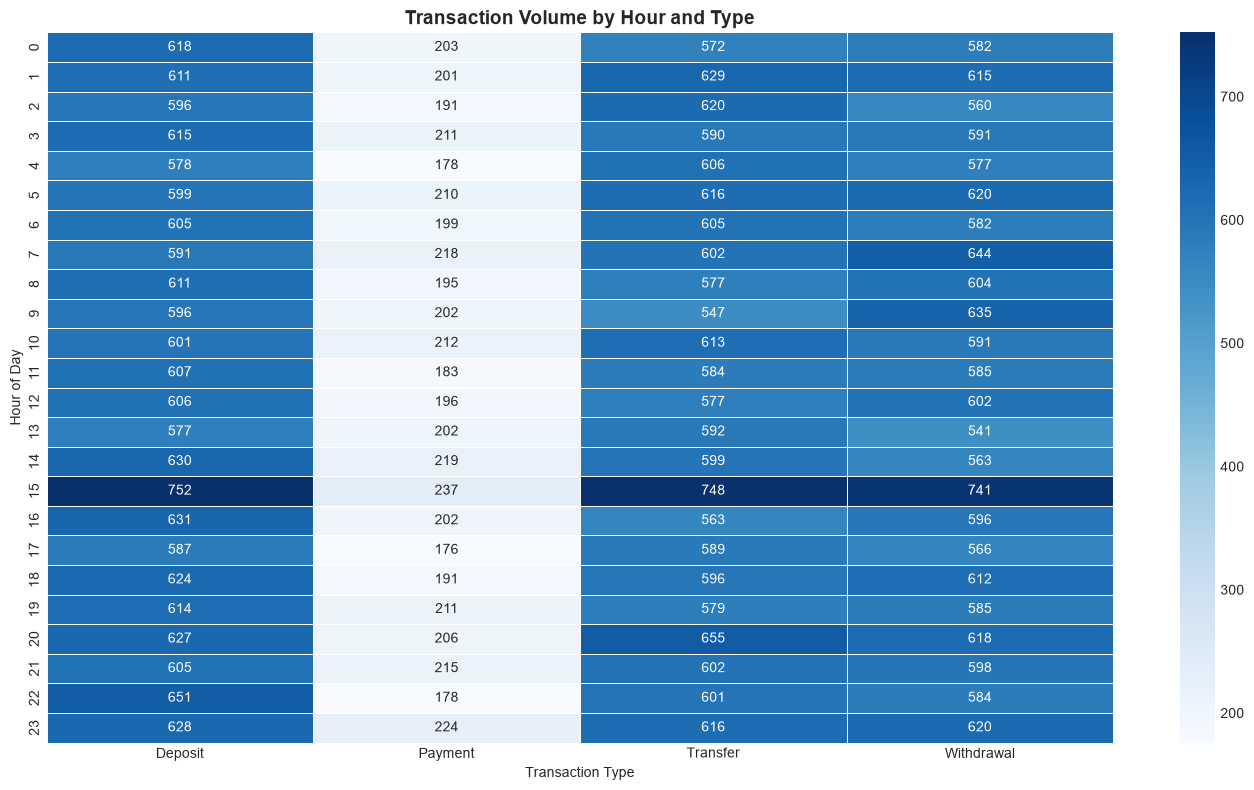

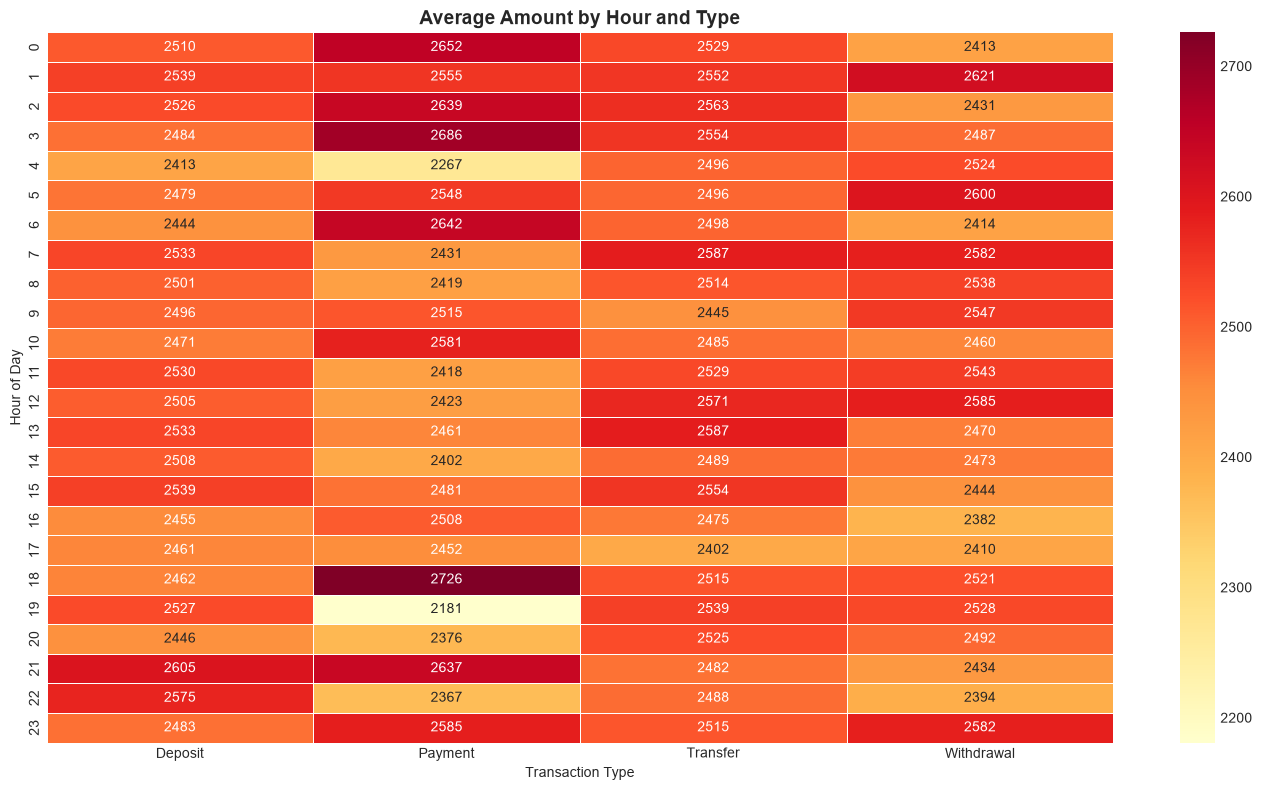

In [37]:
print("\n" + "="*80)
print("📅 QUESTION 7: How do amount, time, and type interact?")
print("="*80)

if 'TransactionDate' in df_trans.columns and 'TypeName' in df_trans.columns:
    df_trans['TransactionDate'] = pd.to_datetime(df_trans['TransactionDate'])
    df_trans['Hour'] = df_trans['TransactionDate'].dt.hour
    df_trans['DayOfWeek'] = df_trans['TransactionDate'].dt.day_name()
    
    # Hourly patterns by transaction type
    hourly_pattern = df_trans.groupby(['Hour', 'TypeName']).size().reset_index(name='Count')
    
    # Plot heatmap
    pivot_hourly = hourly_pattern.pivot(index='Hour', columns='TypeName', values='Count').fillna(0)
    
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_hourly, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)
    plt.title('Transaction Volume by Hour and Type', fontsize=14, fontweight='bold')
    plt.xlabel('Transaction Type')
    plt.ylabel('Hour of Day')
    plt.tight_layout()
    plt.show()
    
    # Average amount by hour and type
    hourly_amount = df_trans.groupby(['Hour', 'TypeName'])['Amount'].mean().reset_index(name='Avg_Amount')
    pivot_hourly_amount = hourly_amount.pivot(index='Hour', columns='TypeName', values='Avg_Amount').fillna(0)
    
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_hourly_amount, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Average Amount by Hour and Type', fontsize=14, fontweight='bold')
    plt.xlabel('Transaction Type')
    plt.ylabel('Hour of Day')
    plt.tight_layout()
    plt.show()

In [38]:
print("\n" + "="*80)
print("✅ MULTIVARIATE ANALYSIS COMPLETED!")
print("="*80)
print("\n📌 Key Takeaways:")
print("   • Transaction amount varies by type AND branch")
print("   • Account balance, transaction count, and account type are interrelated")
print("   • Customer type affects account behavior and transaction patterns")
print("   • Loan amount and interest rate vary by loan status")
print("   • There are hourly patterns in transaction activity by type")


print("="*80)


✅ MULTIVARIATE ANALYSIS COMPLETED!

📌 Key Takeaways:
   • Transaction amount varies by type AND branch
   • Account balance, transaction count, and account type are interrelated
   • Customer type affects account behavior and transaction patterns
   • Loan amount and interest rate vary by loan status
   • There are hourly patterns in transaction activity by type


In [39]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, f_classif


🎯 Creating Target Variable: High-Value Transactions
✅ Loaded 48,510 transactions

📊 Target Distribution:
   Threshold: $4,501.86
   High-Value Transactions: 4,851 (10.0%)
   Regular Transactions: 43,659 (90.0%)


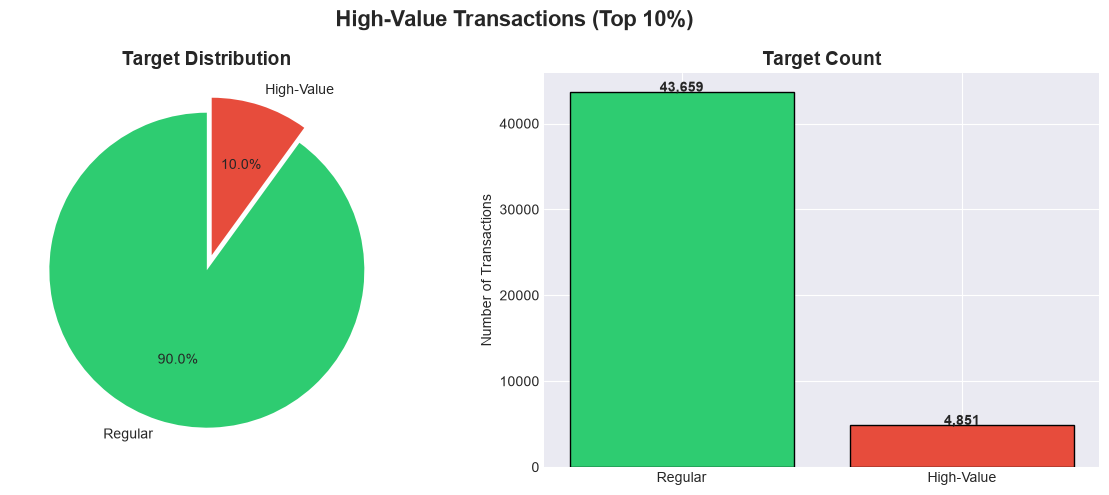

In [40]:
print("\n🎯 Creating Target Variable: High-Value Transactions")
print("="*80)

# Load transactions data
df_trans = pd.read_csv('../data/eda/transactions_unified.csv')
print(f"✅ Loaded {df_trans.shape[0]:,} transactions")

# Create target: High-value transaction (top 10% by amount)
threshold = df_trans['Amount'].quantile(0.90)
df_trans['is_high_value'] = (df_trans['Amount'] > threshold).astype(int)

print(f"\n📊 Target Distribution:")
print(f"   Threshold: ${threshold:,.2f}")
print(f"   High-Value Transactions: {df_trans['is_high_value'].sum():,} ({(df_trans['is_high_value'].sum()/len(df_trans))*100:.1f}%)")
print(f"   Regular Transactions: {len(df_trans) - df_trans['is_high_value'].sum():,} ({((len(df_trans) - df_trans['is_high_value'].sum())/len(df_trans))*100:.1f}%)")

# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels = ['Regular', 'High-Value']
sizes = [len(df_trans) - df_trans['is_high_value'].sum(), df_trans['is_high_value'].sum()]
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.1))
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(labels, sizes, color=colors, edgecolor='black')
axes[1].set_title('Target Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('High-Value Transactions (Top 10%)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
print("\n" + "="*80)
print("🔍 Preparing Features for Analysis")
print("="*80)

# Define features to analyze
features_to_analyze = {
    'numerical': ['Amount', 'Balance', 'OriginBalance', 'DestBalance', 'TransactionCount'],
    'categorical': ['TypeName', 'BranchName', 'OriginAccountTypeID', 'DestAccountTypeID']
}

# Filter columns that exist
numerical_features = [col for col in features_to_analyze['numerical'] if col in df_trans.columns]
categorical_features = [col for col in features_to_analyze['categorical'] if col in df_trans.columns]

print(f"\n📊 Features Selected for Analysis:")
print(f"   Numerical: {len(numerical_features)} features")
print(f"   Categorical: {len(categorical_features)} features")


🔍 Preparing Features for Analysis

📊 Features Selected for Analysis:
   Numerical: 3 features
   Categorical: 4 features



🔢 NUMERICAL FEATURE ANALYSIS

📊 Analyzing: Amount
----------------------------------------
   High-Value: mean=4751.45, median=4753.59, std=143.72
   Regular:    mean=2254.61, median=2256.85, std=1298.49
   Difference: 2496.84
   Mann-Whitney U test: statistic=211789809.0000, p-value=0.0000
   Result: ✅ Significant
   Effect Size (Cohen's d): 2.703


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

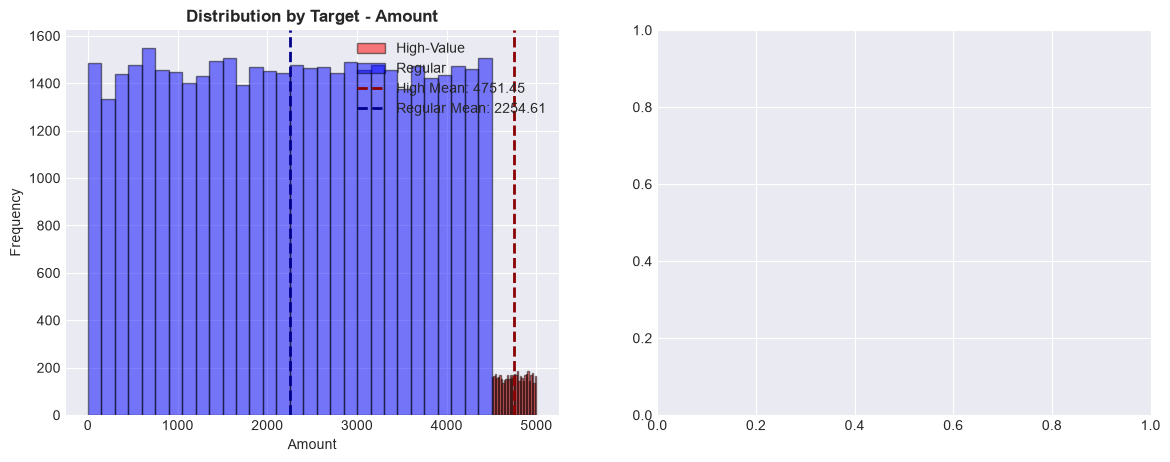

In [42]:
print("\n" + "="*80)
print("🔢 NUMERICAL FEATURE ANALYSIS")
print("="*80)

numerical_results = []

for feature in numerical_features:
    print(f"\n📊 Analyzing: {feature}")
    print("-" * 40)
    
    # Split data by target
    high_val = df_trans[df_trans['is_high_value'] == 1][feature]
    regular = df_trans[df_trans['is_high_value'] == 0][feature]
    
    # Calculate statistics
    print(f"   High-Value: mean={high_val.mean():.2f}, median={high_val.median():.2f}, std={high_val.std():.2f}")
    print(f"   Regular:    mean={regular.mean():.2f}, median={regular.median():.2f}, std={regular.std():.2f}")
    
    # Difference
    diff = high_val.mean() - regular.mean()
    print(f"   Difference: {diff:.2f}")
    
    # Statistical test (Mann-Whitney U test for non-normal distributions)
    stat, p_value = stats.mannwhitneyu(high_val, regular, alternative='two-sided')
    print(f"   Mann-Whitney U test: statistic={stat:.4f}, p-value={p_value:.4f}")
    
    significance = "✅ Significant" if p_value < 0.05 else "❌ Not significant"
    print(f"   Result: {significance}")
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((high_val.std()**2 + regular.std()**2) / 2)
    cohens_d = diff / pooled_std if pooled_std > 0 else 0
    print(f"   Effect Size (Cohen's d): {cohens_d:.3f}")
    
    numerical_results.append({
        'Feature': feature,
        'Diff_Mean': diff,
        'P_Value': p_value,
        'Significant': p_value < 0.05,
        'Effect_Size': cohens_d
    })
    
    # Plot distribution comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(high_val.dropna(), bins=30, alpha=0.5, color='red', label='High-Value', edgecolor='black')
    axes[0].hist(regular.dropna(), bins=30, alpha=0.5, color='blue', label='Regular', edgecolor='black')
    axes[0].axvline(high_val.mean(), color='darkred', linestyle='--', linewidth=2, label=f'High Mean: {high_val.mean():.2f}')
    axes[0].axvline(regular.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Regular Mean: {regular.mean():.2f}')
    axes[0].set_title(f'Distribution by Target - {feature}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    
    # Boxplot
    data_to_plot = [regular.dropna(), high_val.dropna()]
    axes[1].boxplot(data_to_plot, labels=['Regular', 'High-Value'], patch_artist=True)
    axes[1].set_title(f'Boxplot by Target - {feature}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(feature)
    
    plt.suptitle(f'{feature} - High-Value vs Regular Transactions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Summary of numerical features
numerical_df = pd.DataFrame(numerical_results).sort_values('P_Value')
print("\n📊 Numerical Feature Summary:")
print(numerical_df.to_string(index=False))


📝 CATEGORICAL FEATURE ANALYSIS

📊 Analyzing: TypeName
----------------------------------------
   Contingency Table:
is_high_value      0     1
TypeName                  
Deposit        13297  1463
Payment         4361   499
Transfer       13005  1473
Withdrawal     12996  1416

   High-Value Percentage by Category:
TypeName
Payment       10.27
Transfer      10.17
Deposit        9.91
Withdrawal     9.83
Name: 1, dtype: float64

   Chi-Square Test: χ²=1.4905, p-value=0.6845
   Result: ❌ Not significant


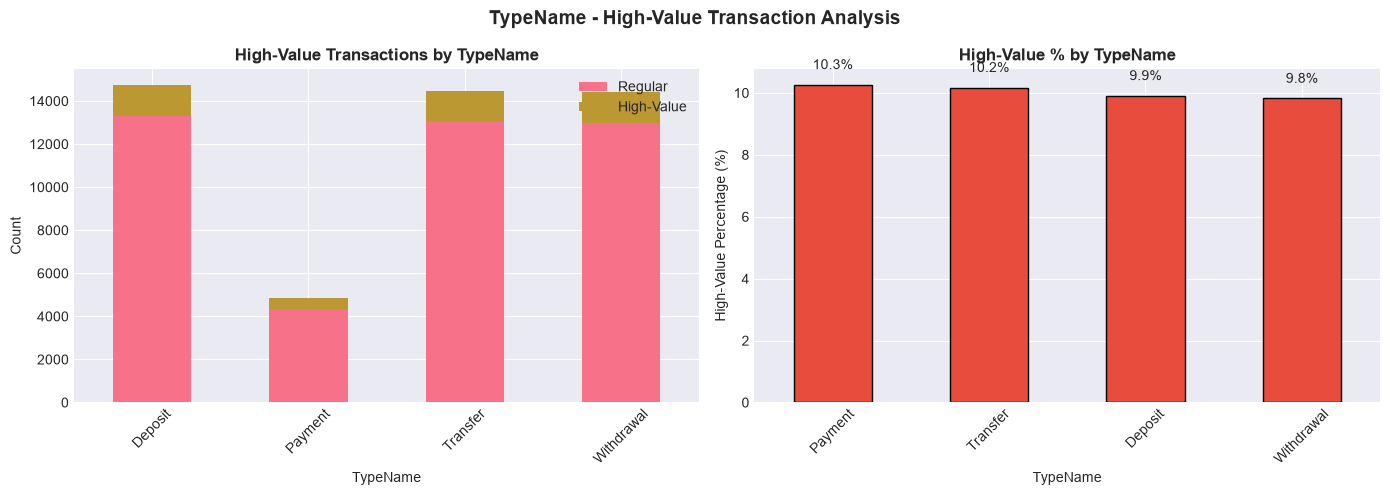


📊 Analyzing: BranchName
----------------------------------------
   Contingency Table:
is_high_value    0    1
BranchName             
Branch 1       897   87
Branch 10      870   92
Branch 11      826   88
Branch 12      888   82
Branch 13      773  108
Branch 14      891   89
Branch 15      904  109
Branch 16      883   84
Branch 17      865  103
Branch 18      886   98
Branch 19      819   94
Branch 2       858   97
Branch 20      875   80
Branch 21      881  105
Branch 22      894   85
Branch 23      850   92
Branch 24      859  123
Branch 25      905   97
Branch 26      881   82
Branch 27      917   98
Branch 28      847  109
Branch 29      879  109
Branch 3       856  101
Branch 30      880   83
Branch 31      860   94
Branch 32      861   97
Branch 33      844   88
Branch 34      880  106
Branch 35      877   96
Branch 36      868  100
Branch 37      859   87
Branch 38      850  110
Branch 39      887   98
Branch 4       860   95
Branch 40      822   99
Branch 41      852  106


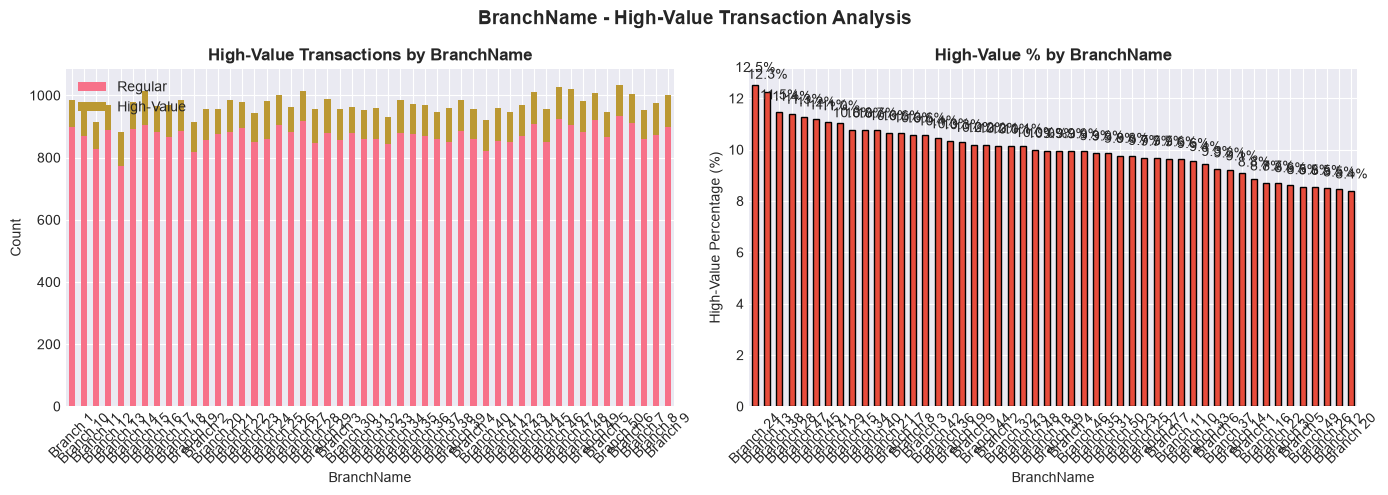


📊 Analyzing: OriginAccountTypeID
----------------------------------------
   Contingency Table:
is_high_value           0     1
OriginAccountTypeID            
1                    8318   902
2                    8597   999
3                    8215   891
4                    9693  1071
5                    8836   988

   High-Value Percentage by Category:
OriginAccountTypeID
2    10.41
5    10.06
4     9.95
3     9.78
1     9.78
Name: 1, dtype: float64

   Chi-Square Test: χ²=2.8138, p-value=0.5894
   Result: ❌ Not significant


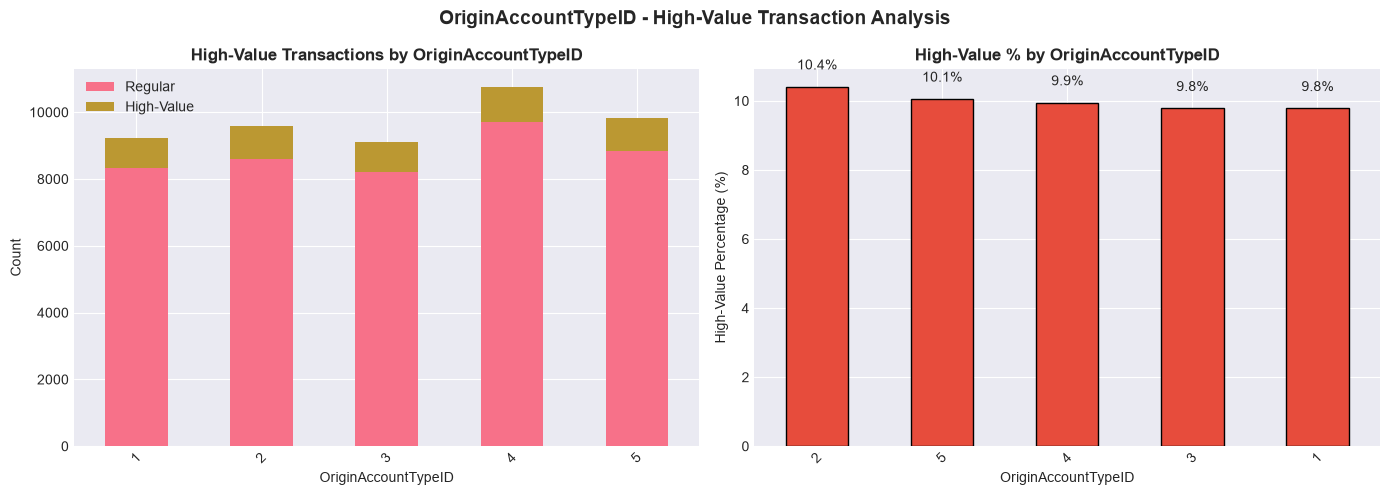


📊 Analyzing: DestAccountTypeID
----------------------------------------
   Contingency Table:
is_high_value         0     1
DestAccountTypeID            
1                  8321   927
2                  8635   982
3                  8072   855
4                  9731  1037
5                  8900  1050

   High-Value Percentage by Category:
DestAccountTypeID
5    10.55
2    10.21
1    10.02
4     9.63
3     9.58
Name: 1, dtype: float64

   Chi-Square Test: χ²=7.2635, p-value=0.1226
   Result: ❌ Not significant


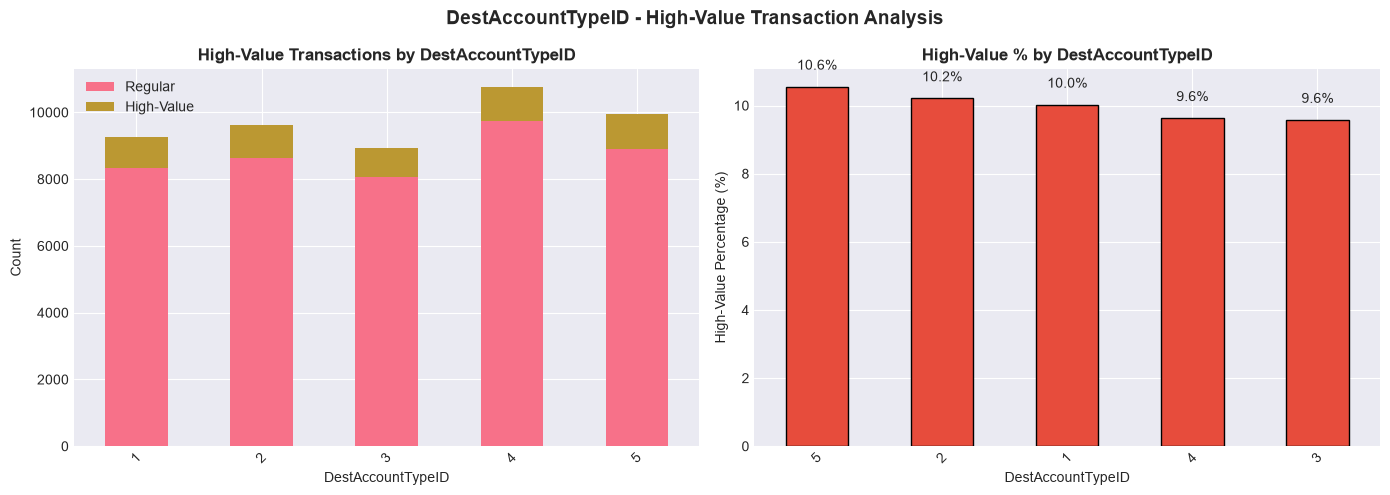


📊 Categorical Feature Summary:
            Feature      Chi2  P_Value  Significant  Max_Diff
  DestAccountTypeID  7.263471 0.122603        False  0.975078
         BranchName 49.064372 0.470545        False  4.148495
OriginAccountTypeID  2.813826 0.589449        False  0.627507
           TypeName  1.490547 0.684454        False  0.442344


In [43]:
print("\n" + "="*80)
print("📝 CATEGORICAL FEATURE ANALYSIS")
print("="*80)

categorical_results = []

for feature in categorical_features:
    print(f"\n📊 Analyzing: {feature}")
    print("-" * 40)
    
    # Create contingency table
    contingency = pd.crosstab(df_trans[feature], df_trans['is_high_value'])
    print(f"   Contingency Table:")
    print(contingency)
    
    # Calculate percentages
    percentages = contingency.div(contingency.sum(axis=1), axis=0) * 100
    print(f"\n   High-Value Percentage by Category:")
    print(percentages[1].sort_values(ascending=False).round(2))
    
    # Chi-square test
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    print(f"\n   Chi-Square Test: χ²={chi2:.4f}, p-value={p_value:.4f}")
    
    significance = "✅ Significant" if p_value < 0.05 else "❌ Not significant"
    print(f"   Result: {significance}")
    
    categorical_results.append({
        'Feature': feature,
        'Chi2': chi2,
        'P_Value': p_value,
        'Significant': p_value < 0.05,
        'Max_Diff': (percentages[1].max() - percentages[1].min()) if len(percentages) > 0 else 0
    })
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Stacked bar chart
    contingency.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title(f'High-Value Transactions by {feature}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')
    axes[0].legend(['Regular', 'High-Value'])
    axes[0].tick_params(axis='x', rotation=45)
    
    # High-value percentage by category
    percentages[1].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black')
    axes[1].set_title(f'High-Value % by {feature}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('High-Value Percentage (%)')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(percentages[1].sort_values(ascending=False)):
        axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')
    
    plt.suptitle(f'{feature} - High-Value Transaction Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Summary of categorical features
categorical_df = pd.DataFrame(categorical_results).sort_values('P_Value')
print("\n📊 Categorical Feature Summary:")
print(categorical_df.to_string(index=False))


🏆 FEATURE IMPORTANCE RANKING

📊 Feature Importance Ranking:
            Feature        Type  Importance_Score  P_Value  Significant  Effect_Size
             Amount   Numerical         10.000000 0.000000         True     2.702862
  DestAccountTypeID Categorical          0.911499 0.122603        False     0.975078
         BranchName Categorical          0.327399 0.470545        False     4.148495
OriginAccountTypeID Categorical          0.229554 0.589449        False     0.627507
           TypeName Categorical          0.164656 0.684454        False     0.442344


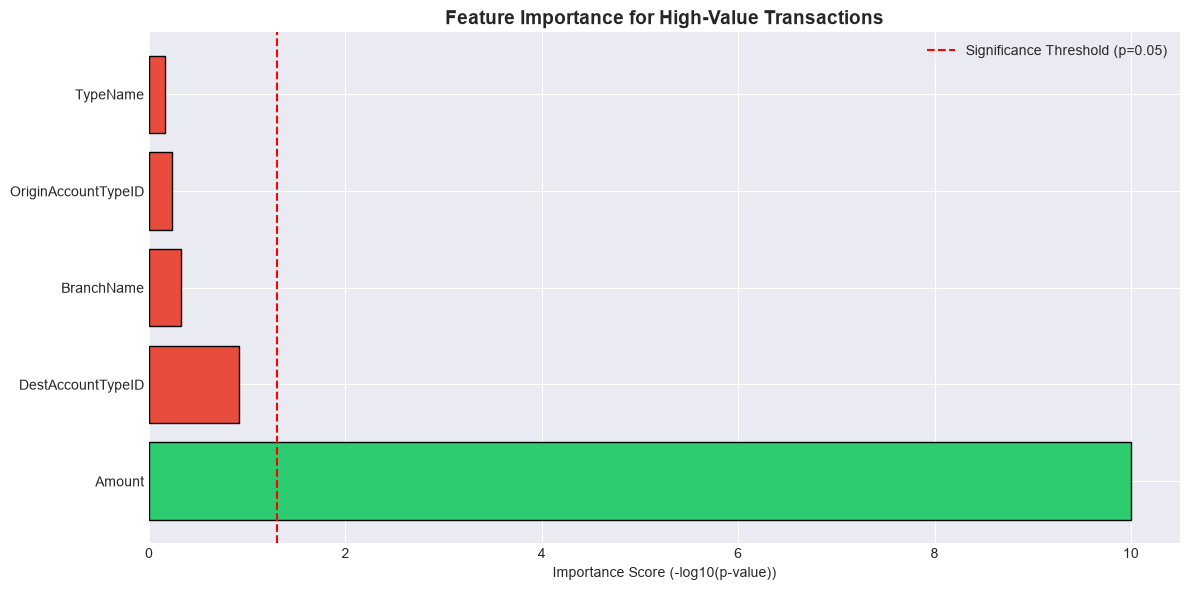

In [44]:
print("\n" + "="*80)
print("🏆 FEATURE IMPORTANCE RANKING")
print("="*80)

# Combine all results
all_features = []

# Add numerical features
for result in numerical_results:
    all_features.append({
        'Feature': result['Feature'],
        'Type': 'Numerical',
        'Importance_Score': -np.log10(result['P_Value'] + 1e-10),  # Log of p-value
        'P_Value': result['P_Value'],
        'Significant': result['Significant'],
        'Effect_Size': result.get('Effect_Size', 0)
    })

# Add categorical features
for result in categorical_results:
    all_features.append({
        'Feature': result['Feature'],
        'Type': 'Categorical',
        'Importance_Score': -np.log10(result['P_Value'] + 1e-10),
        'P_Value': result['P_Value'],
        'Significant': result['Significant'],
        'Effect_Size': result.get('Max_Diff', 0)
    })

# Sort by importance
feature_importance = pd.DataFrame(all_features).sort_values('Importance_Score', ascending=False)

print("\n📊 Feature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if sig else '#e74c3c' for sig in feature_importance['Significant']]
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance_Score'], color=colors, edgecolor='black')
plt.xlabel('Importance Score (-log10(p-value))')
plt.title('Feature Importance for High-Value Transactions', fontsize=14, fontweight='bold')
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold (p=0.05)')
plt.legend()
plt.tight_layout()
plt.show()



🔍 DEEP DIVE: Top Predictors Analysis

📊 Top 3 Most Important Features:
   1. Amount
   2. DestAccountTypeID
   3. BranchName


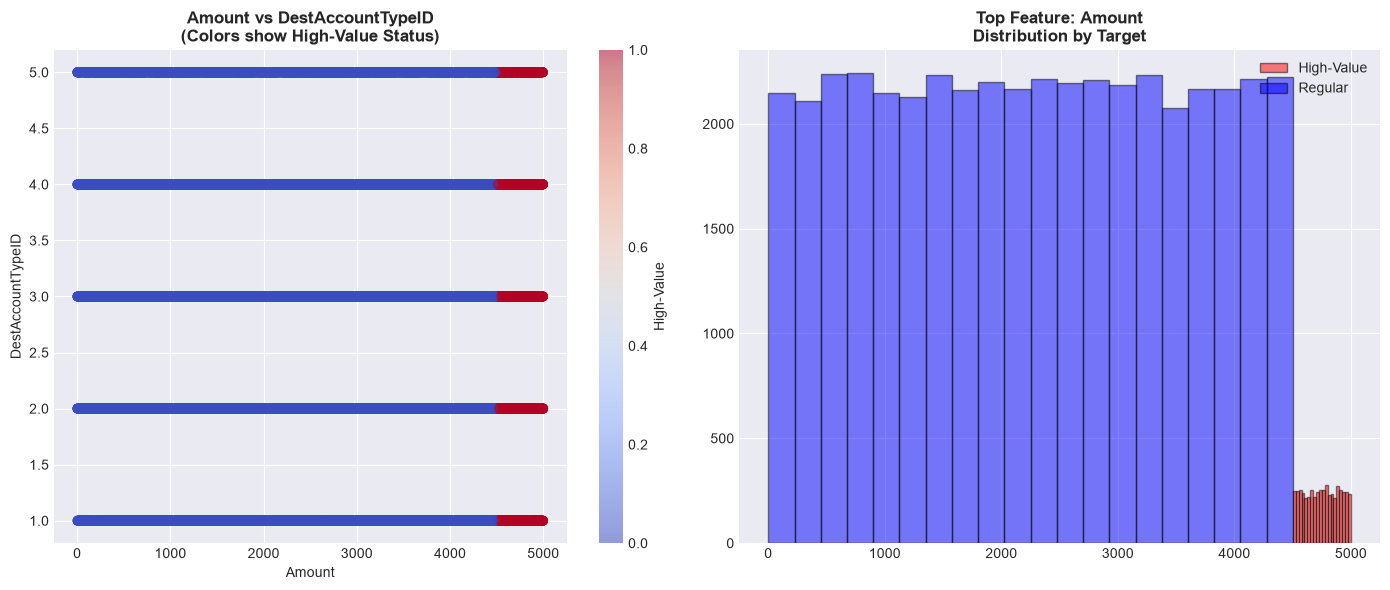

In [45]:
print("\n" + "="*80)
print("🔍 DEEP DIVE: Top Predictors Analysis")
print("="*80)

# Get top 3 features
top_features = feature_importance.head(3)['Feature'].tolist()
print(f"\n📊 Top 3 Most Important Features:")
for i, feature in enumerate(top_features, 1):
    print(f"   {i}. {feature}")

# Analyze interactions between top features
if len(top_features) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Feature 1 vs Feature 2 with target overlay
    feature1 = top_features[0]
    feature2 = top_features[1] if len(top_features) > 1 else top_features[0]
    
    if feature1 in df_trans.columns and feature2 in df_trans.columns:
        # Scatter plot for numerical-numerical combination
        if pd.api.types.is_numeric_dtype(df_trans[feature1]) and pd.api.types.is_numeric_dtype(df_trans[feature2]):
            scatter = axes[0].scatter(
                df_trans[feature1],
                df_trans[feature2],
                c=df_trans['is_high_value'],
                alpha=0.5,
                cmap='coolwarm'
            )
            axes[0].set_title(f'{feature1} vs {feature2}\n(Colors show High-Value Status)', fontsize=12, fontweight='bold')
            axes[0].set_xlabel(feature1)
            axes[0].set_ylabel(feature2)
            plt.colorbar(scatter, ax=axes[0], label='High-Value')
        
        # Boxplot for categorical-numerical combination
        elif pd.api.types.is_numeric_dtype(df_trans[feature1]) and not pd.api.types.is_numeric_dtype(df_trans[feature2]):
            df_trans.boxplot(column=feature1, by=feature2, ax=axes[0])
            axes[0].set_title(f'{feature1} by {feature2}', fontsize=12, fontweight='bold')
            axes[0].tick_params(axis='x', rotation=45)
        elif not pd.api.types.is_numeric_dtype(df_trans[feature1]) and pd.api.types.is_numeric_dtype(df_trans[feature2]):
            df_trans.boxplot(column=feature2, by=feature1, ax=axes[0])
            axes[0].set_title(f'{feature2} by {feature1}', fontsize=12, fontweight='bold')
            axes[0].tick_params(axis='x', rotation=45)
        else:
            # Both categorical - stacked bar
            pd.crosstab(df_trans[feature1], df_trans[feature2]).plot(kind='bar', stacked=True, ax=axes[0])
            axes[0].set_title(f'{feature1} vs {feature2}', fontsize=12, fontweight='bold')
            axes[0].tick_params(axis='x', rotation=45)
    
    # Feature distribution by target for top feature
    if top_features:
        feature = top_features[0]
        if feature in df_trans.columns:
            high_val = df_trans[df_trans['is_high_value'] == 1][feature]
            regular = df_trans[df_trans['is_high_value'] == 0][feature]
            
            if pd.api.types.is_numeric_dtype(df_trans[feature]):
                axes[1].hist(high_val.dropna(), bins=20, alpha=0.5, color='red', label='High-Value', edgecolor='black')
                axes[1].hist(regular.dropna(), bins=20, alpha=0.5, color='blue', label='Regular', edgecolor='black')
                axes[1].set_title(f'Top Feature: {feature}\nDistribution by Target', fontsize=12, fontweight='bold')
                axes[1].legend()
            else:
                # Categorical - show percentages
                pct = pd.crosstab(df_trans[feature], df_trans['is_high_value'], normalize='index') * 100
                pct[1].sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[1], color='#e74c3c')
                axes[1].set_title(f'Top Feature: {feature}\nHigh-Value % by Category', fontsize=12, fontweight='bold')
                axes[1].set_ylabel('High-Value Percentage (%)')
                axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [46]:
print("\n" + "="*80)
print("📊 FEATURE-TARGET ANALYSIS SUMMARY")
print("="*80)

print("\n📌 Key Findings:")
print("="*80)

# Count significant features
significant_count = feature_importance[feature_importance['Significant']].shape[0]
total_features = feature_importance.shape[0]

print(f"\n✅ Significant Features: {significant_count}/{total_features} (p < 0.05)")

print("\n🏆 Most Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']} ({row['Type']}) - Score: {row['Importance_Score']:.2f}")

print("\n💡 Insights:")
print("   • These features are most predictive of high-value transactions")
print("   • Can be used as input features for fraud/anomaly detection models")
print("   • Consider these for feature engineering and model development")

print("\n📋 Recommended Next Steps:")
print("   1. Use these features for predictive modeling")
print("   2. Consider feature interactions in model design")
print("   3. Validate findings with domain expertise")

print("\n" + "="*80)
print("✅ FEATURE-TARGET ANALYSIS COMPLETED!")
print("="*80)


📊 FEATURE-TARGET ANALYSIS SUMMARY

📌 Key Findings:

✅ Significant Features: 1/5 (p < 0.05)

🏆 Most Important Features:
   Amount (Numerical) - Score: 10.00
   DestAccountTypeID (Categorical) - Score: 0.91
   BranchName (Categorical) - Score: 0.33
   OriginAccountTypeID (Categorical) - Score: 0.23
   TypeName (Categorical) - Score: 0.16

💡 Insights:
   • These features are most predictive of high-value transactions
   • Can be used as input features for fraud/anomaly detection models
   • Consider these for feature engineering and model development

📋 Recommended Next Steps:
   1. Use these features for predictive modeling
   2. Consider feature interactions in model design
   3. Validate findings with domain expertise

✅ FEATURE-TARGET ANALYSIS COMPLETED!
